Loaded 1000 trajectories from 'Car_trajectories_dataset.npy'
Example traj keys: dict_keys(['states', 'controls'])
states.shape = (100, 5) controls.shape = (100, 2)
Train loader ready, #batches = 16


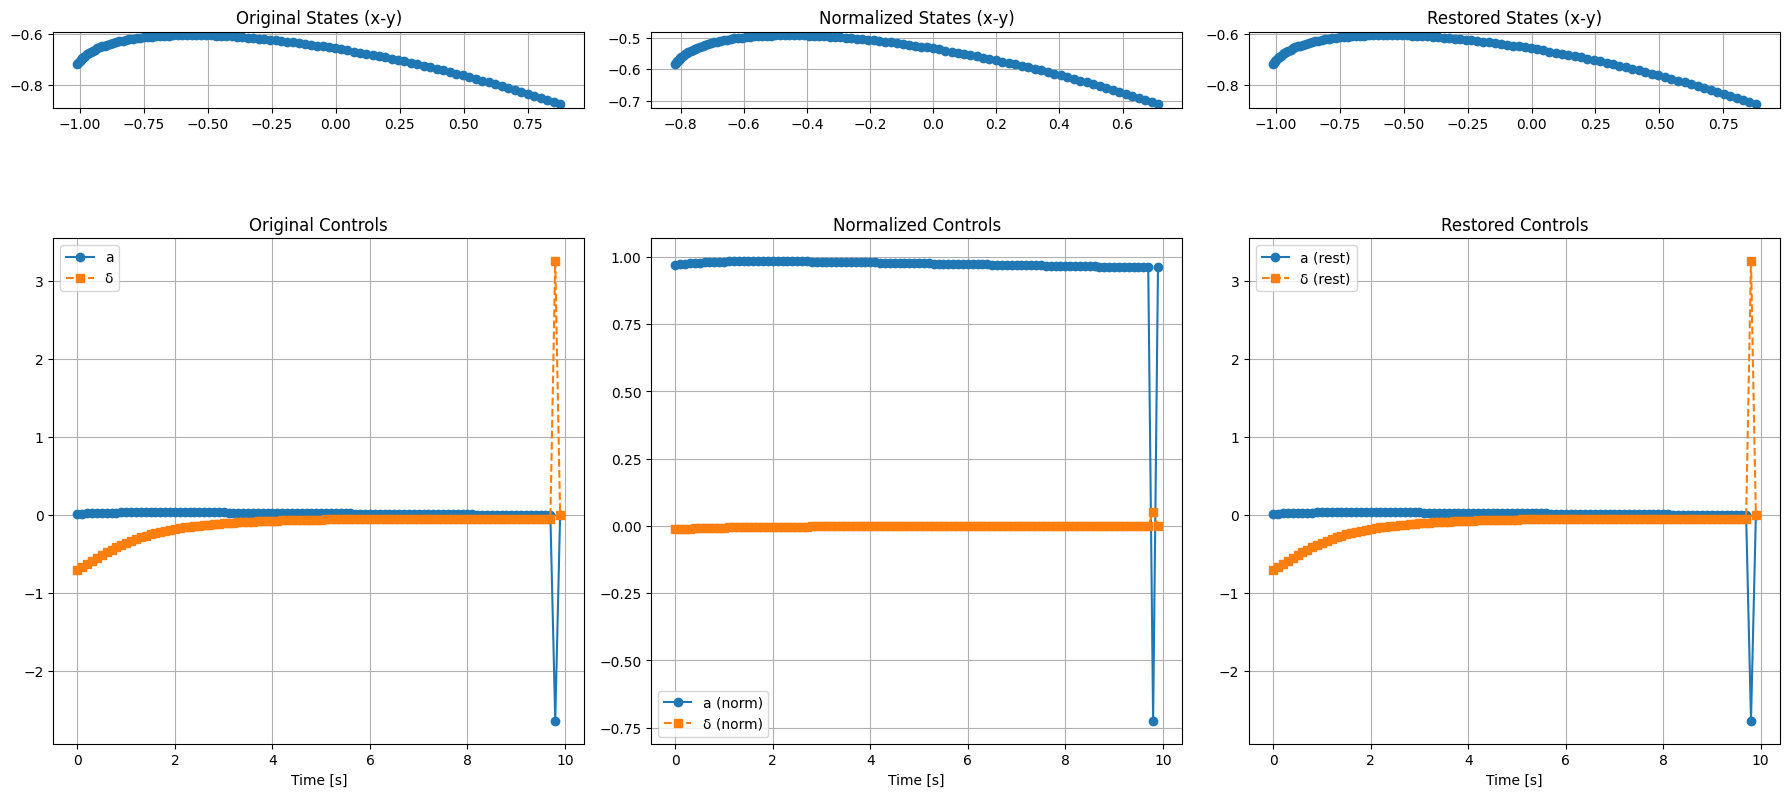

In [1]:
# Cell 1: Import all required libraries and dependencies
%load_ext autoreload
%autoreload 2
import math
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import LambdaLR
import torchdiffeq

# fmtorch imports
from fmtorch.scheduler import CondOTScheduler
from fmtorch.path import AffinePath
from fmtorch.solver import ODESolver
from fmtorch.utils import ModelWrapper
from fmtorch.models import UNetModel

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import os

# ----------------------------
# Parameters
# ----------------------------
state_steps = 100                  # total number of states (includes initial state)
control_steps = state_steps - 1    # number of control steps to simulate state updates
dt = 0.1                           # time step (seconds)
a_max = 0.25                       # maximum longitudinal acceleration [m/s^2]
delta_max = 0.2                    # maximum steering angle [rad]

# Weights in the cost function
w_p = 10.0      # weight for terminal position error
w_theta = 1.0   # weight for terminal heading error
w_v = 1.0       # weight for terminal speed and yaw rate error (both desired 0)
lambda_reg = 0.1  # regularization for control effort

# ----------------------------
# Configuration for data generation
# ----------------------------
num_trajectories = 1000
save_filename = 'Car_trajectories_dataset.npy'
LOAD_SAVED_DATA = False 
progress_step = max(num_trajectories // 10, 1)

# ----------------------------
# Utility Functions
# ----------------------------
def sample_point_in_circle(center, radius):
    """
    Sample a random point inside a circle with specified center and radius.
    """
    angle = np.random.uniform(0, 2*np.pi)
    r = radius * np.sqrt(np.random.uniform(0, 1))
    return center + r * np.array([np.cos(angle), np.sin(angle)])

def simulate_vehicle(x0, u_seq, dt=0.1):
    #接收初始状态 $x_0$ 和一系列控制输入 $u_{seq}$，计算出车辆在 $T = \text{control\_steps} \times dt$ 时间内的状态轨迹。
    #使用欧拉离散化的五状态模型（状态 $x = [x, y, \theta, v, r]$，其中 $x, y$ 是位置，$\theta$ 是航向角，$v$ 是速度，$r$ 是横摆角速度）
    #
    """
    Simulate the vehicle dynamics.
    
    x0: initial state [x, y, theta, v, r]
    u_seq: control sequence of shape (control_steps, 2), for each step: [a, delta]
    
    The vehicle dynamics (using Euler discretization):
      x_{k+1} = x_k + dt * v_k * cos(theta_k)
      y_{k+1} = y_k + dt * v_k * sin(theta_k)
      theta_{k+1} = theta_k + dt * r_k
      v_{k+1} = v_k + dt * a_k
      r_{k+1} = r_k + dt * delta_k
      
    Returns:
      states: NumPy array of shape (state_steps, 5)
    """
    states = np.zeros((state_steps, 5))
    states[0] = x0
    # For k=0,...,control_steps-1, apply optimized control
    for k in range(control_steps):
        x, y, theta, v, r = states[k]
        a, delta = u_seq[k]
        x_next = x + dt * v * np.cos(theta)
        y_next = y + dt * v * np.sin(theta)
        theta_next = theta + dt * r
        v_next = v + dt * a
        r_next = r + dt * delta
        states[k+1] = [x_next, y_next, theta_next, v_next, r_next]
    return states


def cost_function(u_flat, x0, target, dt, control_steps, 
                  lambda_reg=lambda_reg, w_p=w_p, w_theta=w_theta, w_v=w_v):
    """
    Cost function for optimal control.
    
    The cost includes:
      1. Terminal state error: 
         - Position error: ||[x_N, y_N] - target||^2 
         - Heading error: (theta_N - 0)^2 (target heading fixed at 0 rad)
         - Speed error: (v_N - 0)^2
         - Yaw rate error: (r_N - 0)^2
      2. Control effort penalty: lambda_reg * sum(a_k^2 + delta_k^2) over all steps
    """
    u_seq = u_flat.reshape((control_steps, 2))
    states = simulate_vehicle(x0, u_seq, dt)
    final_state = states[-1]
    pos_error = np.linalg.norm(final_state[:2] - target)**2
    theta_error = (final_state[2] - 0)**2   # desired heading 0 rad
    v_error = (final_state[3] - 0)**2         # desired speed 0
    r_error = (final_state[4] - 0)**2         # desired yaw rate 0
    control_penalty = lambda_reg * np.sum(u_seq**2)
    J = w_p * pos_error + w_theta * theta_error + w_v * (v_error + r_error) + control_penalty
    return J

# ----------------------------
# Optimization Bounds and Setup
# ----------------------------
# Since we optimize for control_steps steps, total decision variables: control_steps * 2
bounds = []
for _ in range(control_steps):
    bounds.append((-a_max, a_max))       # for a_k
    bounds.append((-delta_max, delta_max)) # for delta_k

import os
import numpy as np

filename = 'Car_trajectories_dataset.npy'
assert os.path.exists(filename), f"{filename} not found!"

trajectories = np.load(filename, allow_pickle=True)

print(f"Loaded {len(trajectories)} trajectories from '{filename}'")
print("Example traj keys:", trajectories[0].keys())
print("states.shape =", trajectories[0]['states'].shape,
      "controls.shape =", trajectories[0]['controls'].shape)
from torch.utils.data import Dataset, DataLoader
import torch
batch_size=64
traj_arr = np.stack([
    np.concatenate([traj['states'][:, :3].T,
                    traj['controls'][:100].T], axis=0)
    for traj in trajectories
], axis=0).astype(np.float32)  # shape (N,5,100)

class TrajectoryDataset(Dataset):
    def __init__(self, data):
        self.data = data
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        return torch.from_numpy(self.data[idx])  # FloatTensor

train_loader = DataLoader(
    TrajectoryDataset(traj_arr),
    batch_size=batch_size, shuffle=True, num_workers=0
)

print("Train loader ready, #batches =", len(train_loader))
import numpy as np
import matplotlib.pyplot as plt

# 数据归一化至[-1,1]
class Scaler:
    
    def __init__(self, data_min, data_max):

        self.min = data_min
        self.max = data_max
    
    def normalize(self, x):

        return 2 * (x - self.min) / (self.max - self.min) - 1
    
    def denormalize(self, x_norm):

        return (x_norm + 1) / 2 * (self.max - self.min) + self.min

try:
    trajectories
except NameError:
    trajectories = np.load('Car_trajectories_dataset.npy', allow_pickle=True)

all_states   = np.vstack([traj['states']   for traj in trajectories])  # (num_traj*state_steps, 5)
all_controls = np.vstack([traj['controls'] for traj in trajectories])  # (num_traj*state_steps, 2)

state_min,   state_max   = all_states.min(axis=0),   all_states.max(axis=0)
control_min, control_max = all_controls.min(axis=0), all_controls.max(axis=0)

state_scaler   = Scaler(state_min,   state_max)
control_scaler = Scaler(control_min, control_max)

idx = np.random.randint(len(trajectories))
sample = trajectories[idx]
orig_states   = sample['states']    # shape=(state_steps, 5)
orig_controls = sample['controls']  # shape=(state_steps, 2)

norm_states   = state_scaler.normalize(orig_states)
rest_states   = state_scaler.denormalize(norm_states)

norm_controls = control_scaler.normalize(orig_controls)
rest_controls = control_scaler.denormalize(norm_controls)

dt = 0.1
time_ctrl = np.arange(orig_controls.shape[0]) * dt

fig, axs = plt.subplots(2, 3, figsize=(18, 10))

axs[0, 0].plot(orig_states[:,0],   orig_states[:,1],   'o-')
axs[0, 0].set_title('Original States (x-y)')
axs[0, 0].set_aspect('equal', 'box')
axs[0, 0].grid(True)

axs[0, 1].plot(norm_states[:,0],   norm_states[:,1],   'o-')
axs[0, 1].set_title('Normalized States (x-y)')
axs[0, 1].set_aspect('equal', 'box')
axs[0, 1].grid(True)

axs[0, 2].plot(rest_states[:,0],   rest_states[:,1],   'o-')
axs[0, 2].set_title('Restored States (x-y)')
axs[0, 2].set_aspect('equal', 'box')
axs[0, 2].grid(True)

axs[1, 0].plot(time_ctrl, orig_controls[:,0], 'o-', label='a')
axs[1, 0].plot(time_ctrl, orig_controls[:,1], 's--', label='δ')
axs[1, 0].set_title('Original Controls')
axs[1, 0].set_xlabel('Time [s]')
axs[1, 0].legend()
axs[1, 0].grid(True)

axs[1, 1].plot(time_ctrl, norm_controls[:,0], 'o-', label='a (norm)')
axs[1, 1].plot(time_ctrl, norm_controls[:,1], 's--', label='δ (norm)')
axs[1, 1].set_title('Normalized Controls')
axs[1, 1].set_xlabel('Time [s]')
axs[1, 1].legend()
axs[1, 1].grid(True)

axs[1, 2].plot(time_ctrl, rest_controls[:,0], 'o-', label='a (rest)')
axs[1, 2].plot(time_ctrl, rest_controls[:,1], 's--', label='δ (rest)')
axs[1, 2].set_title('Restored Controls')
axs[1, 2].set_xlabel('Time [s]')
axs[1, 2].legend()
axs[1, 2].grid(True)

plt.tight_layout()
plt.show()


In [2]:
# ==== 0. Imports & Setup ====
import math
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import LambdaLR

# fmtorch imports
from fmtorch.scheduler import CondOTScheduler
from fmtorch.path import AffinePath
from fmtorch.solver import ODESolver
from fmtorch.utils import ModelWrapper
from fmtorch.models import UNetModel

class Scaler:
    def __init__(self, data_min, data_max):
        self.min = data_min
        self.max = data_max
    
    def normalize(self, x):
        return 2 * (x - self.min) / (self.max - self.min) - 1
    
    def denormalize(self, x_norm):
        return (x_norm + 1) / 2 * (self.max - self.min) + self.min

# ==== 1. Constants ====
dt = 0.1
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
batch_size = 64
#n_epochs = 4500
n_epochs=1
lr = 1e-4
warmup_epochs = int(0.1 * n_epochs)
report_interval = max(1, n_epochs // 10)

# ==== 2. Compute min/max only on used dims & init scalers ====
all_states_s = np.vstack([traj['states'][:, :3]     for traj in trajectories])  # shape (N*100, 3)
all_controls = np.vstack([traj['controls'][:100]    for traj in trajectories])  # shape (N*100, 2)

state_min, state_max   = all_states_s.min(axis=0),   all_states_s.max(axis=0)   # (3,), (3,)
ctrl_min,  ctrl_max    = all_controls.min(axis=0),   all_controls.max(axis=0)    # (2,), (2,)

state_scaler   = Scaler(state_min, state_max)
control_scaler = Scaler(ctrl_min,  ctrl_max)

# ==== 3. Dataset & DataLoader (保持不变) ====
class TrajectoryDataset(Dataset):
    def __init__(self, trajectories, state_scaler, control_scaler):
        self.trajs = trajectories
        self.state_s = state_scaler
        self.ctrl_s = control_scaler

    def __len__(self):
        return len(self.trajs)

    def __getitem__(self, idx):
        traj = self.trajs[idx]
        s = traj['states'][:, :3]     # (100,3)
        c = traj['controls'][:100]    # (100,2)
        s_norm = self.state_s.normalize(s)
        c_norm = self.ctrl_s.normalize(c)
        sample = np.concatenate([s_norm.T, c_norm.T], axis=0).astype(np.float32)  # (5,100)
        return torch.from_numpy(sample)

train_loader = DataLoader(
    TrajectoryDataset(trajectories, state_scaler, control_scaler),
    batch_size=batch_size, shuffle=True, num_workers=0
)




# ==== 5. 模型组件 (保持不变) ====
class Mish(nn.Module):
    def forward(self, x):
        return x * torch.tanh(F.softplus(x))

class ResidualFC(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.fc1 = nn.Linear(dim, dim)
        self.fc2 = nn.Linear(dim, dim)
        self.act = Mish()
    
    def forward(self, x):
        out = self.act(self.fc1(x))
        out = self.fc2(out)
        return self.act(out + x)

class UpSampler(nn.Module):
    def __init__(self, in_shape=(5,100), out_shape=(1,28,28), width=1024, depth=5):
        super().__init__()
        in_dim, out_dim = np.prod(in_shape), np.prod(out_shape)
        layers = [nn.Linear(in_dim, width), Mish()]
        for _ in range(depth-2):
            layers.append(ResidualFC(width))
        layers.append(nn.Linear(width, out_dim))
        self.net = nn.Sequential(*layers)
        self.norm = nn.LayerNorm(out_dim)
        self.out_shape = out_shape
    
    def forward(self, x):
        x = x.flatten(1)
        x = self.net(x)
        x = self.norm(x)
        return x.view(x.size(0), *self.out_shape)

class DownSampler(nn.Module):
    def __init__(self, in_shape=(1,28,28), out_shape=(5,100), width=1024, depth=5):
        super().__init__()
        in_dim, out_dim = np.prod(in_shape), np.prod(out_shape)
        layers = [nn.Linear(in_dim, width), Mish()]
        for _ in range(depth-2):
            layers.append(ResidualFC(width))
        layers.append(nn.Linear(width, out_dim))
        self.net = nn.Sequential(*layers)
        self.out_shape = out_shape
    
    def forward(self, x):
        x = x.flatten(1)
        x = self.net(x)
        return x.view(x.size(0), *self.out_shape)

class ChannelAttention(nn.Module):
    def __init__(self, channels, ratio=8):
        super().__init__()
        hidden = max(channels // ratio, 1)
        self.avg = nn.AdaptiveAvgPool2d(1)
        self.max = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(
            nn.Conv2d(channels, hidden, 1, bias=False), Mish(),
            nn.Conv2d(hidden, channels, 1, bias=False), nn.Sigmoid()
        )
    
    def forward(self, x):
        att = self.fc(self.avg(x) + self.max(x))
        return x * att

class SpatialAttention(nn.Module):
    def __init__(self, k=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=k, padding=k//2, bias=False)
    
    def forward(self, x):
        avg = x.mean(1, keepdim=True)
        mx, _ = x.max(1, keepdim=True)
        att = torch.sigmoid(self.conv(torch.cat([avg, mx], 1)))
        return x * att

class UNetWithAttention(UNetModel):
    def __init__(self, dim, num_channels, num_res_blocks, num_classes, class_cond):
        super().__init__(
            image_size=dim[-1],
            in_channels=dim[0],
            model_channels=num_channels,
            out_channels=dim[0],
            num_res_blocks=num_res_blocks,
            attention_resolutions=(16,),
            channel_mult=(1, 2, 2),
            num_classes=num_classes if class_cond else None
        )
        in_ch = dim[0]
        self.ca = ChannelAttention(in_ch)
        self.sa = SpatialAttention()
    
    def forward(self, t, x, y=None):
        feat = super().forward(t, x, y)
        feat = self.ca(feat)
        feat = self.sa(feat)
        return feat

# ==== 6. 创建fmtorch兼容的流模型 ====
class CarTrajectoryFlowModel(ModelWrapper):
    def __init__(self, upsampler, unet_model, downsampler):
        nn.Module.__init__(self)  # 直接初始化nn.Module
        self.upsampler = upsampler
        self.unet = unet_model
        self.downsampler = downsampler
    
    def forward(self, x: torch.Tensor, t: torch.Tensor, **extras):
        # x shape: (batch_size, 5, 100)
        # t shape: (batch_size,)
        
        # 上采样到图像空间
        x_img = self.upsampler(x)  # (batch_size, 1, 28, 28)
        
        # 为UNet准备dummy标签
        batch_size = x.shape[0]
        dummy_label = torch.zeros(batch_size, dtype=torch.long, device=x.device)
        
        # 通过UNet
        v_img = self.unet(t, x_img, dummy_label)
        
        # 下采样回轨迹空间
        v_traj = self.downsampler(v_img)  # (batch_size, 5, 100)
        
        return v_traj

# ==== 7. 初始化模型和优化器 ====
upsampler = UpSampler().to(device)
downsampler = DownSampler().to(device)
unet = UNetWithAttention(
    dim=(1, 28, 28), 
    num_channels=32, 
    num_res_blocks=2,
    num_classes=10, 
    class_cond=True
).to(device)

# 创建fmtorch流模型
flow_model = CarTrajectoryFlowModel(upsampler, unet, downsampler)

# 优化器
optim = torch.optim.Adam(
    list(upsampler.parameters()) +
    list(downsampler.parameters()) +
    list(unet.parameters()), 
    lr=lr
)

# 学习率调度器
scheduler = LambdaLR(
    optim, lr_lambda=lambda epoch: (
        float(epoch) / warmup_epochs if epoch < warmup_epochs else
        0.5*(1.0 + math.cos(math.pi*(epoch - warmup_epochs)/(n_epochs - warmup_epochs)))
    )
)

# ==== 初始化fmtorch组件 ====
path = AffinePath(scheduler=CondOTScheduler())



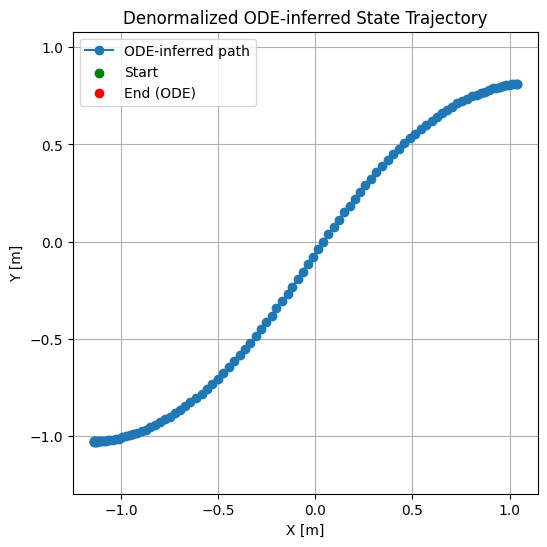

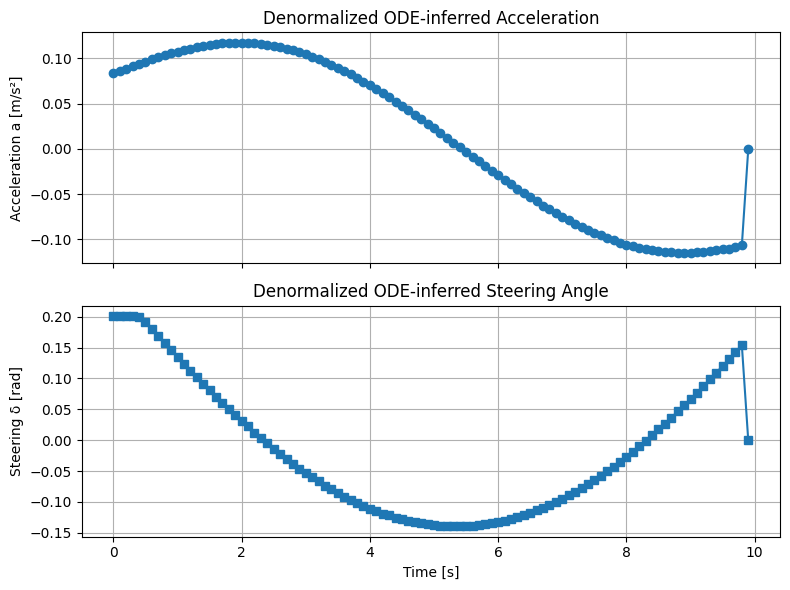

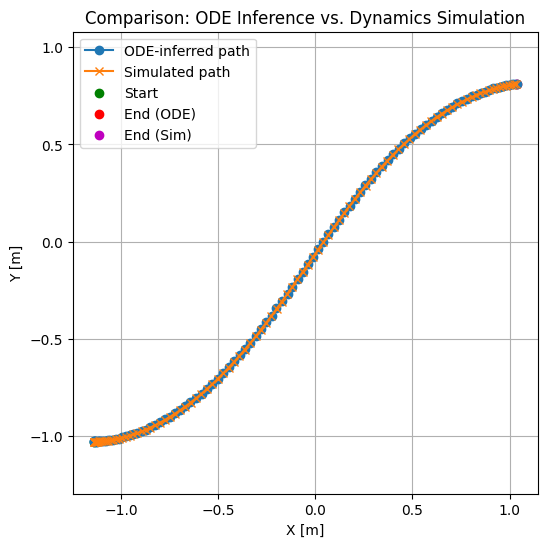

In [3]:
import torch
import torchdiffeq
import numpy as np
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ckpt = torch.load('fmtorch_best_ckpt_epoch4400.pt', map_location=device)
upsampler.load_state_dict(ckpt['upsampler'])
downsampler.load_state_dict(ckpt['downsampler'])
unet.load_state_dict(ckpt['unet'])
upsampler.eval()
downsampler.eval()
unet.eval()

# 2. Perform ODE-based flow-matching inference (in normalized space)
with torch.no_grad():
    x0_noise = torch.randn((1, 5, state_steps), device=device)
    t_span = torch.linspace(0., 1., 2, device=device)

    def fm_ode_func(t, x_flat):
        x = x_flat.view(1, 5, state_steps)
        img = upsampler(x)
        labels = torch.zeros((1,), dtype=torch.long, device=device)
        v_img = unet(t, img, labels)
        v_traj = downsampler(v_img)
        return v_traj.view(-1)

    traj_t = torchdiffeq.odeint(
        fm_ode_func,
        x0_noise.view(-1),
        t_span,
        atol=1e-5,
        rtol=1e-5,
        method='dopri5'
    )
    x_fm_norm = traj_t[-1].view(5, state_steps).cpu().numpy()  # shape: (5, 100)

# 3. Split into states and controls, then denormalize
states_norm   = x_fm_norm[:3, :].T   # (100, 3): [x, y, theta]
controls_norm = x_fm_norm[3:5, :].T  # (100, 2): [accel, steer]

states   = state_scaler.denormalize(states_norm)      # (100, 3)
controls = control_scaler.denormalize(controls_norm)  # (100, 2)

# 4. Visualize the inferred state trajectory and control sequence
time = np.linspace(0, (state_steps-1)*dt, state_steps)

plt.figure(figsize=(6,6))
plt.plot(states[:,0], states[:,1], '-o', label='ODE-inferred path')
plt.scatter(states[0,0], states[0,1], c='g', label='Start')
plt.scatter(states[-1,0], states[-1,1], c='r', label='End (ODE)')
plt.title('Denormalized ODE-inferred State Trajectory')
plt.xlabel('X [m]')
plt.ylabel('Y [m]')
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.show()

fig, (ax1, ax2) = plt.subplots(2,1, figsize=(8,6), sharex=True)
ax1.plot(time, controls[:,0], '-o')
ax1.set_ylabel('Acceleration a [m/s²]')
ax1.set_title('Denormalized ODE-inferred Acceleration')
ax1.grid(True)

ax2.plot(time, controls[:,1], '-s')
ax2.set_ylabel('Steering δ [rad]')
ax2.set_xlabel('Time [s]')
ax2.set_title('Denormalized ODE-inferred Steering Angle')
ax2.grid(True)

plt.tight_layout()
plt.show()

# 5. Simulate vehicle dynamics with the inferred controls and compare
x0_state = np.concatenate([states[0], [0.0, 0.0]])  # [x0, y0, theta0, v0=0, r0=0]
sim_states = simulate_vehicle(x0=x0_state, u_seq=controls[:control_steps], dt=dt)

plt.figure(figsize=(6,6))
plt.plot(states[:,0],     states[:,1],     '-o', label='ODE-inferred path')
plt.plot(sim_states[:,0], sim_states[:,1], '-x', label='Simulated path')
plt.scatter(states[0,0], states[0,1], c='g', label='Start')
plt.scatter(states[-1,0], states[-1,1], c='r', label='End (ODE)')
plt.scatter(sim_states[-1,0], sim_states[-1,1], c='m', label='End (Sim)')
plt.title('Comparison: ODE Inference vs. Dynamics Simulation')
plt.xlabel('X [m]')
plt.ylabel('Y [m]')
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.show()


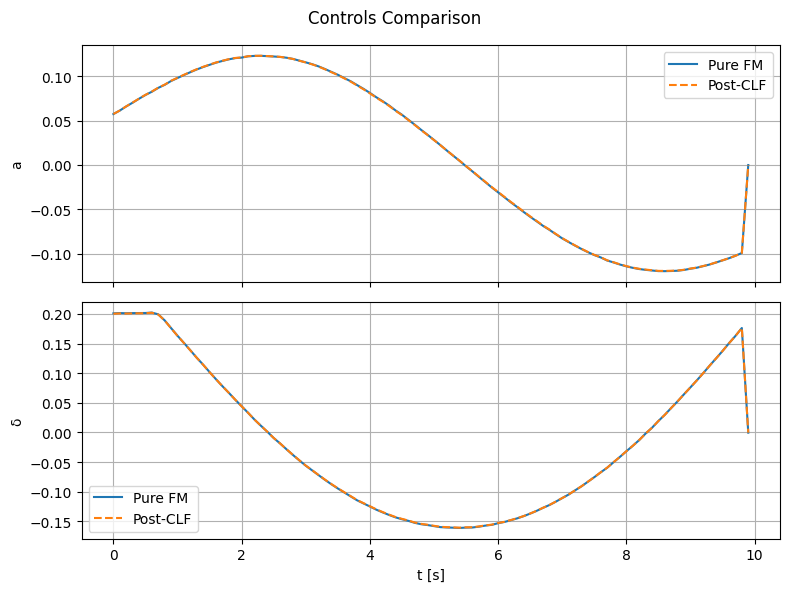

RMSE Pure FM:  0.0033 m
RMSE Post-CLF: 0.0022 m


In [ ]:
# === Cell: FM Sampling + Post‐CLF Correction (自适应 Dormand–Prince 5) ===

import torch
import torchdiffeq
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# --- 1. QP‐based CLF 校正 & 参数 ---
clf_params = {
    'a_max':      0.9,
    'delta_max':  0.9,
    'beta':     1e2,
    'lambda_reg':1e2,
    'mask':       0.0,
    'cap':      1e3,
    'dt':         0.1,
    't_frac':     1.0
}

def time_blow_up_function(t, T=1.0, cap=1e3):
    phi = 1.0 / (T - t + 1e-8)
    return min(phi, cap)

# 后校正（Post‐CLF）：一次性对整条轨迹做 CLF 校正
# 输入：
# states_phys：物理状态序列，形状为 (N, 5)，N 是轨迹点数，5 是状态维度（x, y, theta, v, r）
# controls_phys：物理控制序列，形状为 (N, 2)，2 是控制维度（a, delta）
# clf_params：CLF 校正参数，字典类型
# 输出：
# 校正后的控制序列，形状为 (N, 2)，2 是控制维度（a, delta）

def correct_with_clf(states_phys, controls_phys, clf_params):
    N = states_phys.shape[0]
    a_max, d_max = clf_params['a_max'], clf_params['delta_max']
    λ_reg, β     = clf_params['lambda_reg'], clf_params['beta']
    cap, dt      = clf_params['cap'], clf_params['dt']
    phi  = time_blow_up_function(clf_params['t_frac'], cap=cap)
    w_s  = phi / (1.0 + phi)

    x0 = np.array([*states_phys[0], 0.0, 0.0], dtype=np.float32)
    u0 = np.zeros(N*2, dtype=np.float32)

    def obj(du_flat):
        du = du_flat.reshape(N,2)
        U  = controls_phys + du
        from __main__ import simulate_vehicle
        pred = simulate_vehicle(x0, U[:-1], dt=dt)[:,:3]
        err  = pred - states_phys
        return β*w_s*np.sum(err**2) + λ_reg*np.sum(du**2)
        # 目标函数：
        # 1. 状态误差平方和，权重为 β*w_s
        # 2. 控制误差平方和，权重为 λ_reg

    bnds = []
    for k in range(N):
        a0,d0 = controls_phys[k]
        bnds += [(-a_max - a0, a_max - a0),
                 (-d_max - d0, d_max - d0)]

    res = minimize(obj, u0, method='SLSQP', bounds=bnds,
                   options={'ftol':1e-6, 'maxiter':200})
    du_opt = res.x.reshape(N,2).astype(np.float32)
    return controls_phys + du_opt
    #使得修正后的控制 $\mathbf{U} = \mathbf{U}_{\text{FM}} + \mathbf{du}$ 

# --- 2. Scaler & 全轨迹 Min/Max ---
class Scaler:
    def __init__(self, data_min, data_max):
        self.min, self.max = data_min, data_max
    def normalize(self, x):
        return 2*(x - self.min)/(self.max - self.min) - 1
    def denormalize(self, x):
        return (x + 1)/2*(self.max - self.min) + self.min

all_data_5d = np.vstack([
    np.hstack([traj['states'][:, :3], traj['controls'][:100]])
    for traj in trajectories
])
dmin, dmax = all_data_5d.min(0), all_data_5d.max(0)
state_scaler = Scaler(dmin, dmax)

# --- 3. 纯 FM 分段采样（dopri5 自适应步长） ---
def piecewise_fm(x0_norm, upsampler, unet, downsampler, num_segments):
    device = x0_norm.device
    times  = torch.linspace(0,1,num_segments+1, device=device)
    state  = x0_norm.clone()

    def ode_func(t, x_flat):
        x   = x_flat.view(1,5,100)
        with torch.no_grad():
            img   = upsampler(x)
            vimg  = unet(t, img, torch.zeros(1, dtype=torch.long, device=device))
            vtraj = downsampler(vimg)
        return vtraj.view(-1)

    for i in range(num_segments):
        tspan = times[i:i+2]
        traj  = torchdiffeq.odeint(ode_func,
                                   state.view(-1),
                                   tspan,
                                   method='dopri5',
                                   atol=1e-5,
                                   rtol=1e-5)
        state = traj[-1].view(1,5,100)
    return state

# --- 4. 后校正（Post‐CLF）：一次性对整条轨迹做 CLF 校正 ---
def post_clf_correction(x_norm, state_scaler, clf_params):
    arr_norm = x_norm.cpu().numpy()[0].T        # (100,5)
    arr_phys = state_scaler.denormalize(arr_norm)  # (100,5)
    S = arr_phys[:,:3]; U = arr_phys[:,3:]
    U_corr = correct_with_clf(S, U, clf_params)     # (100,2)
    arr_phys[:,3:] = U_corr
    arr_norm_corr   = state_scaler.normalize(arr_phys)
    return arr_norm_corr[:,:3], arr_norm_corr[:,3:]

# --- 5. 运行 & 可视化 + RMSE 评估 ---
num_segments = 100
device       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
x0_noise     = torch.randn(1,5,100, device=device)

# ① 纯 FM 采样
state_pure = piecewise_fm(x0_noise, upsampler, unet, downsampler, num_segments)

# ② 后校正

states_norm_corr, controls_norm_corr = post_clf_correction(
    state_pure, state_scaler, clf_params
)

# ③ 提取并反归一化控制
ctrl_pure = control_scaler.denormalize(state_pure.cpu().numpy()[0].T[:,3:])
ctrl_corr = control_scaler.denormalize(controls_norm_corr)

# ④ 绘图比较
t_axis = np.arange(100) * clf_params['dt']
fig,(ax1,ax2)=plt.subplots(2,1,sharex=True,figsize=(8,6))
ax1.plot(t_axis, ctrl_pure[:,0], label='Pure FM')
ax1.plot(t_axis, ctrl_corr[:,0],'--',label='Post-CLF')
ax1.set_ylabel('a'); ax1.legend(); ax1.grid()
ax2.plot(t_axis, ctrl_pure[:,1], label='Pure FM')
ax2.plot(t_axis, ctrl_corr[:,1],'--',label='Post-CLF')
ax2.set_ylabel('δ'); ax2.set_xlabel('t [s]'); ax2.legend(); ax2.grid()
plt.suptitle('Controls Comparison'); plt.tight_layout(); plt.show()

# ⑤ RMSE 计算
arr_phys_fm = state_scaler.denormalize(state_pure.cpu().numpy()[0].T)[:,:3]
sim_fm  = simulate_vehicle(np.concatenate([arr_phys_fm[0],[0,0]]),
                           ctrl_pure[:-1], dt=clf_params['dt'])
sim_corr= simulate_vehicle(np.concatenate([arr_phys_fm[0],[0,0]]),
                           ctrl_corr[:-1], dt=clf_params['dt'])
rmse = lambda A,B: np.sqrt(np.mean(np.sum((A[:,:2]-B[:,:2])**2,axis=1)))
print(f"RMSE Pure FM:  {rmse(arr_phys_fm, sim_fm):.4f} m")
print(f"RMSE Post-CLF: {rmse(arr_phys_fm, sim_corr):.4f} m")


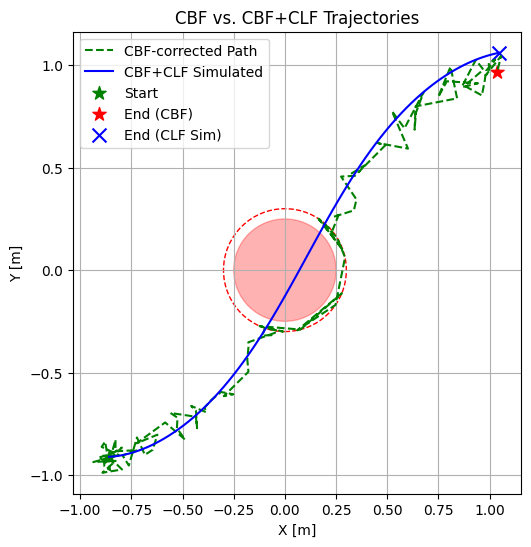

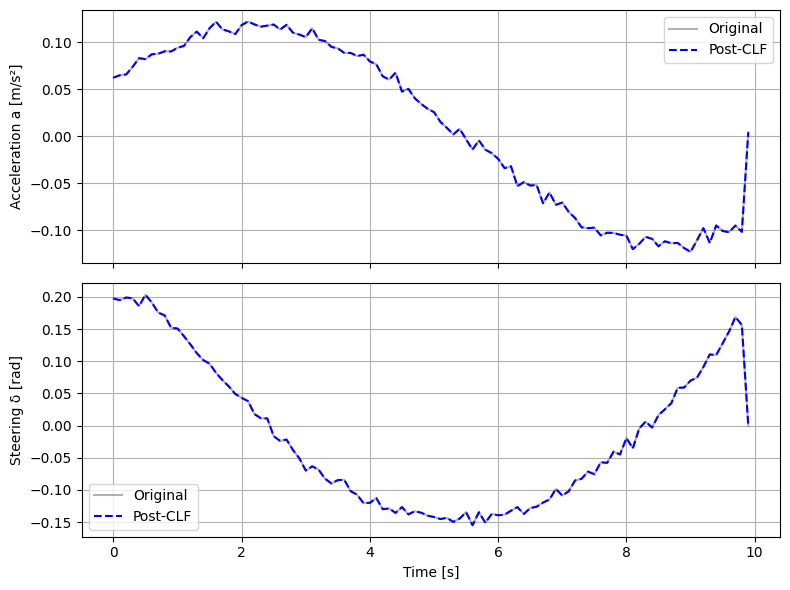

In [7]:
# === Cell: FM Trajectory with CBF + CLF Correction ===
import torch
import torchdiffeq
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Assumes the following are already defined in the environment:
# upsampler, unet, downsampler, state_scaler_3d, control_scaler_2d
# barrier_function, cbf_projection_with_mask, reconstruct_heading_smart, correct_with_clf, simulate_vehicle
# clf_params dict and obstacle parameters from previous cells

# 1. FM sampling (normalized)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
x0_noise = torch.randn((1, 5, state_steps), device=device)
t_span = torch.linspace(0., 1., 2, device=device)

def fm_ode_func(t, x_flat):
    x = x_flat.view(1, 5, state_steps)
    with torch.no_grad():
        img = upsampler(x)
        labels = torch.zeros(1, dtype=torch.long, device=device)
        v_img = unet(t, img, labels)
        v_traj = downsampler(v_img)
    return v_traj.view(-1)

traj_t = torchdiffeq.odeint(
    fm_ode_func,
    x0_noise.view(-1),
    t_span,
    method='dopri5', atol=1e-5, rtol=1e-5
)
x_fm_norm = traj_t[-1].view(5, state_steps).cpu().numpy()

# 2. Denormalize to physical states and controls
states_norm = x_fm_norm[:3, :].T   # (100,3)
controls_norm = x_fm_norm[3:5, :].T  # (100,2)

states_phys = state_scaler_3d.denormalize(states_norm)
controls_phys = control_scaler_2d.denormalize(controls_norm)

# 3. Apply CBF correction on XY and heading
xy_original = states_phys[:, :2]
theta_original = states_phys[:, 2]

xy_cbf, mod_mask = cbf_projection_with_mask(xy_original)
theta_cbf = reconstruct_heading_smart(xy_original, xy_cbf, theta_original, mod_mask)

# Updated states after CBF
states_cbf = np.column_stack([xy_cbf, theta_cbf])

# 4. CLF correction on controls to align with CBF-updated states
controls_cbf = controls_phys.copy()
controls_cbf[:] = controls_phys  # initial guess
# correct_with_clf expects full states (3) and controls (2)
clf_params = {
    'a_max':      1e5,
    'delta_max':  1e5,
    'beta':     1e7,
    'lambda_reg':1e1,
    'mask':       0.0,
    'cap':      1e3,
    'dt':         0.1,
    't_frac':     1.0
}

controls_clf = correct_with_clf(states_cbf, controls_phys, clf_params)

# 5. Simulate dynamics with CLF-corrected controls
dt_val = clf_params['dt']
x0 = np.array([*states_cbf[0], 0.0, 0.0], dtype=np.float32)
sim_states_clf = simulate_vehicle(x0, controls_clf[:-1], dt=dt_val)

# 6. Visualization
fig, ax = plt.subplots(figsize=(6,6))
# Obstacle
guy, center = obstacle_center, obstacle_center
circle = plt.Circle(center, obstacle_radius, color='red', alpha=0.3)
ax.add_patch(circle)
circle_safe = plt.Circle(center, obstacle_radius + safety_margin,
                         fill=False, linestyle='--', color='red')
ax.add_patch(circle_safe)
# Plot trajectories
ax.plot(xy_cbf[:,0], xy_cbf[:,1], 'g--', label='CBF-corrected Path')
ax.plot(sim_states_clf[:,0], sim_states_clf[:,1], 'b-', label='CBF+CLF Simulated')
# Start and end points
ax.scatter(xy_cbf[0,0], xy_cbf[0,1], c='green', marker='*', s=100, label='Start')
ax.scatter(xy_cbf[-1,0], xy_cbf[-1,1], c='red', marker='*', s=100, label='End (CBF)')
ax.scatter(sim_states_clf[-1,0], sim_states_clf[-1,1], c='blue', marker='x', s=100, label='End (CLF Sim)')
ax.set_aspect('equal', 'box')
ax.set_xlabel('X [m]')
ax.set_ylabel('Y [m]')
ax.set_title('CBF vs. CBF+CLF Trajectories')
ax.legend()
ax.grid(True)
plt.show()

# 7. Plot control comparison
time = np.arange(state_steps) * dt_val
fig, (ax1, ax2) = plt.subplots(2,1, sharex=True, figsize=(8,6))
ax1.plot(time, controls_phys[:,0], 'k-', alpha=0.3, label='Original')
ax1.plot(time, controls_clf[:,0], 'b--', label='Post-CLF')
ax1.set_ylabel('Acceleration a [m/s²]')
ax1.legend()
ax1.grid(True)
ax2.plot(time, controls_phys[:,1], 'k-', alpha=0.3, label='Original')
ax2.plot(time, controls_clf[:,1], 'b--', label='Post-CLF')
ax2.set_ylabel('Steering δ [rad]')
ax2.set_xlabel('Time [s]')
ax2.legend()
ax2.grid(True)
plt.tight_layout()
plt.show()


Available keys: ['states_fm', 'states_sim_fm', 'states_sim_post', 'ctrl_fm', 'ctrl_post', 'rmse_fm', 'rmse_post']
Selected trajectory 4
states_fm shape: (100, 3)
ctrl_fm shape: (100, 2)

Iteration 1/3
  Optimization converged. Cost: 0.911734

Iteration 2/3
  Optimization converged. Cost: 0.666889

Iteration 3/3
  Optimization converged. Cost: 0.610970

=== RMSE Comparison ===
Original FM trajectory RMSE: 0.0017 m
CBF-CLF corrected trajectory RMSE: 0.0002 m
RMSE improvement: 89.4%


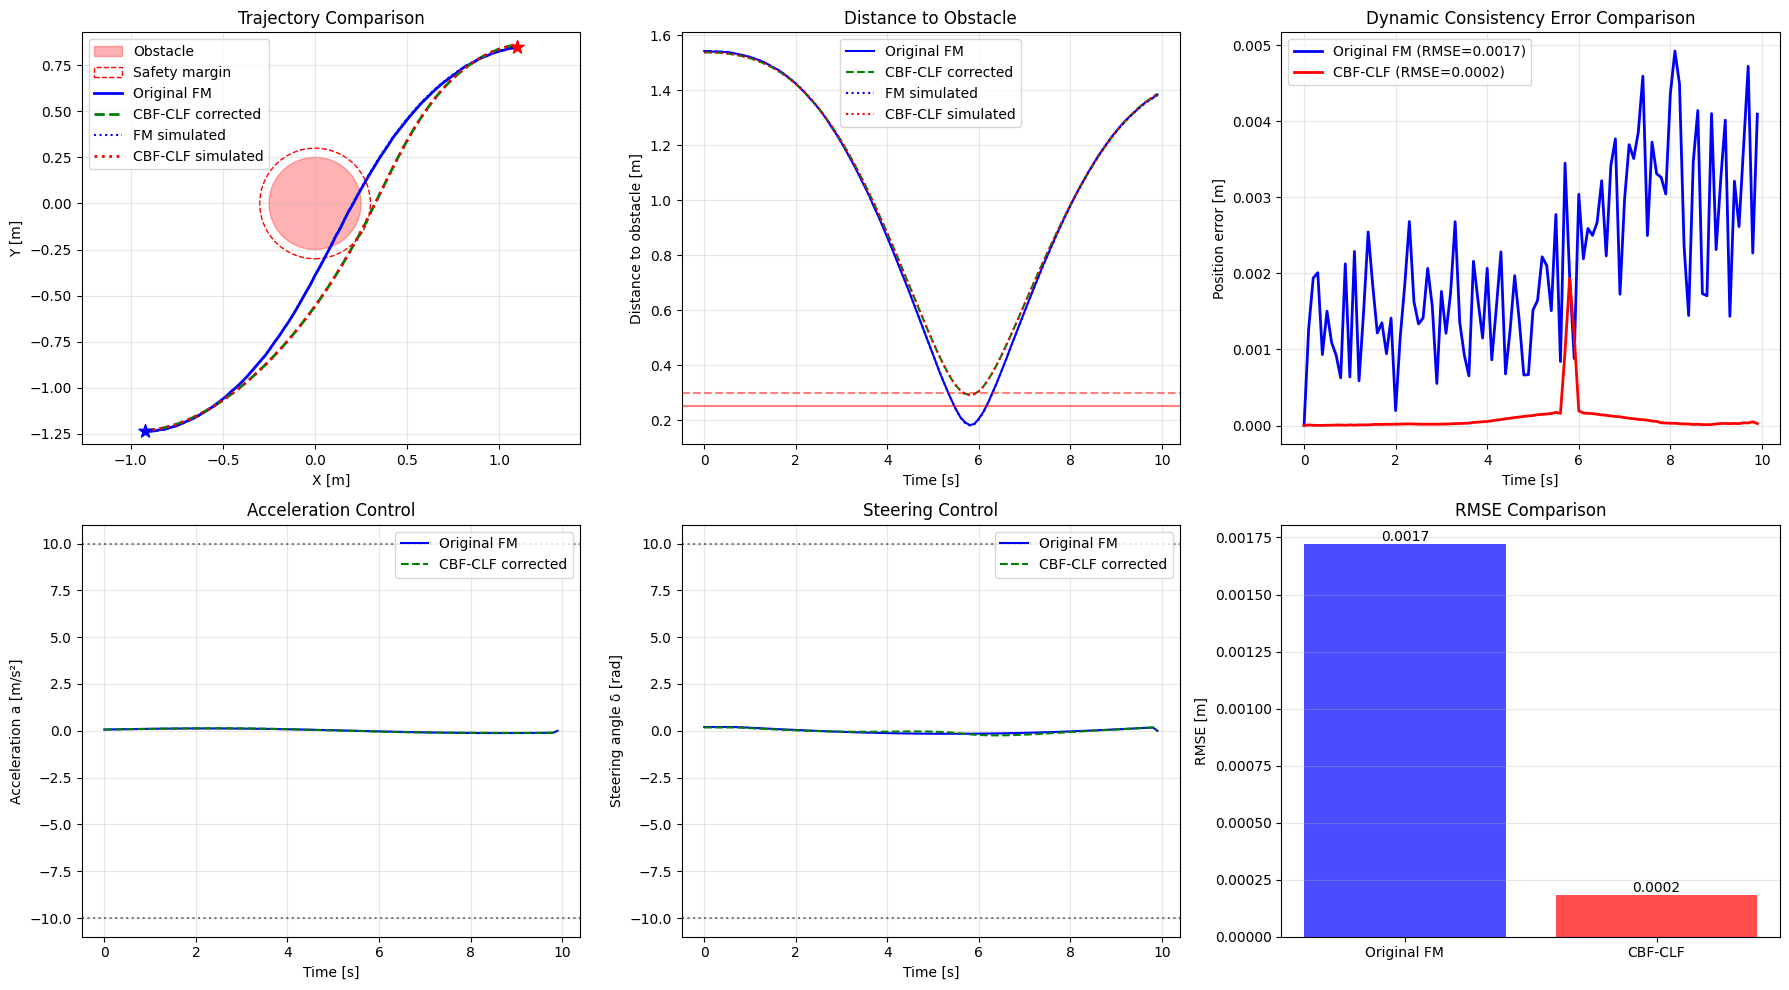


=== Detailed Joint CBF-CLF Optimization Results ===
Minimum distance to obstacle:
  Original FM: 0.1821 m
  CBF-CLF corrected: 0.2925 m
  FM simulated: 0.1805 m
  CBF-CLF simulated: 0.2905 m

Safety violations:
  Original FM: 9
  CBF-CLF corrected: 3
  FM simulated: 10
  CBF-CLF simulated: 3

Trajectory modification:
  Mean state change: 0.0385
  Mean control change: 0.0262


In [34]:
# === Cell: Joint CBF-CLF Optimization (改进版) ===

import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.interpolate import interp1d

# --- 0. 参数设置 ---
# CBF参数
obstacle_center = np.array([0.0, 0.0])
obstacle_radius = 0.25
safety_margin = 0.05

# CLF参数
a_max = 10
delta_max = 10
dt = 0.1

# 权重参数（调整后）
w_dynamics = 5e3     # 降低动态一致性权重
w_state_reg = 0.1     # 降低状态修正正则化权重  
w_control_reg = 1.0   # 降低控制修正正则化权重
epsilon_cbf = 0.001   # CBF松弛变量

# --- 1. 定义Scaler（使用已有的） ---
class Scaler:
    def __init__(self, data_min, data_max):
        self.min = data_min
        self.max = data_max
    
    def normalize(self, x):
        return 2 * (x - self.min) / (self.max - self.min) - 1
    
    def denormalize(self, x_norm):
        return (x_norm + 1) / 2 * (self.max - self.min) + self.min

# --- 2. 加载数据 ---
data = np.load('fm_clf_batch_results.npz')
print("Available keys:", list(data.keys()))

# 选择一条轨迹
i = 4
states_fm = data['states_fm'][i]  # shape=(100,3)
ctrl_fm = data['ctrl_fm'][i]      # shape=(100,2)

print(f"Selected trajectory {i}")
print(f"states_fm shape: {states_fm.shape}")
print(f"ctrl_fm shape: {ctrl_fm.shape}")

# --- 3. 创建Scalers（基于全局统计） ---
all_states_3d = np.vstack([traj['states'][:, :3] for traj in trajectories])
all_controls_2d = np.vstack([traj['controls'][:100] for traj in trajectories])

state_scaler_3d = Scaler(all_states_3d.min(axis=0), all_states_3d.max(axis=0))
control_scaler_2d = Scaler(all_controls_2d.min(axis=0), all_controls_2d.max(axis=0))

# --- 4. 改进的联合CBF-CLF优化函数 ---
def get_initial_cbf_projection(states_phys):
    """获取初始CBF投影作为优化起点"""
    N = states_phys.shape[0]
    states_init = states_phys.copy()
    
    for i in range(N):
        xy = states_phys[i, :2]
        dist = np.linalg.norm(xy - obstacle_center)
        if dist < obstacle_radius + safety_margin:
            # 投影到安全边界
            direction = xy - obstacle_center
            if np.linalg.norm(direction) < 1e-6:
                direction = np.array([1.0, 0.0])
            else:
                direction = direction / np.linalg.norm(direction)
            states_init[i, :2] = obstacle_center + direction * (obstacle_radius + safety_margin + 0.01)
    
    return states_init

def joint_cbf_clf_optimization_improved(states_phys, controls_phys, 
                                       obstacle_center, obstacle_radius, safety_margin,
                                       a_max, delta_max, dt,
                                       w_dynamics, w_state_reg, w_control_reg, epsilon_cbf,
                                       max_iter=3,w_similarity=1.0):
    """
    改进的联合CBF-CLF优化，使用迭代策略
    """
    N = states_phys.shape[0]
    
    # 获取初始CBF投影
    states_init = get_initial_cbf_projection(states_phys)
    states_original = states_phys.copy()
    # 当前最优解
    states_best = states_init.copy()
    controls_best = controls_phys.copy()
    
    # 迭代优化
    for iteration in range(max_iter):
        print(f"\nIteration {iteration + 1}/{max_iter}")
        
        # 动态调整权重
        w_dyn_iter = w_dynamics * (0.5 ** iteration)  # 逐步降低动态权重
        
        def objective(dz_flat):
            # 解包修正量
            ds = dz_flat[:3*N].reshape(N, 3)
            du = dz_flat[3*N:].reshape(N, 2)
            
            # 修正后的状态和控制
            states_new = states_best + ds
            controls_new = controls_best + du
            
            # 1. 动态一致性代价
            x0 = np.array([states_new[0,0], states_new[0,1], states_new[0,2], 0.0, 0.0])
            states_sim = simulate_vehicle(x0, controls_new[:-1], dt)[:, :3]
            dynamics_error = np.sum((states_sim - states_new)**2)
            
            # 2. 正则化项
            state_reg = np.sum(ds**2)
            control_reg = np.sum(du**2)

            state_similarity_weighted = (
                np.sum((states_new[:, :2] - states_original[:, :2])**2) * 2.0 +  # x,y位置
                np.sum((states_new[:, 2] - states_original[:, 2])**2) * 0.05      # 航向角
            )
            
            
            # 3. CBF软约束（添加到目标函数）
            cbf_violation = 0
            for k in range(N):
                xy = states_new[k, :2]
                h = np.sum((xy - obstacle_center)**2) - (obstacle_radius + safety_margin)**2
                if h < 0:
                    cbf_violation += (-h) ** 2
            
            # 总代价
            cost = (w_dyn_iter * dynamics_error + 
                   w_state_reg * state_reg + 
                   w_control_reg * control_reg + 
                   1000 * cbf_violation + w_similarity * state_similarity_weighted 
                   )  # CBF违反的惩罚
            
            return cost
        
        # 约束函数（放松版本）
        constraints = []
        
        # CBF约束（只对关键点）
        for k in range(0, N, 5):  # 每5个点检查一次
            def cbf_constraint(dz_flat, k=k):
                ds = dz_flat[:3*N].reshape(N, 3)
                xy_new = states_best[k, :2] + ds[k, :2]
                h = np.sum((xy_new - obstacle_center)**2) - (obstacle_radius + safety_margin - 0.05)**2
                return h
            
            constraints.append({
                'type': 'ineq',
                'fun': lambda dz, k=k: cbf_constraint(dz, k)
            })
        
        # 界限（根据迭代次数调整）
        bounds = []
        state_bound = 0.3 / (iteration + 1)  # 逐步减小修正范围
        for k in range(N):
            bounds.extend([(-state_bound, state_bound), (-state_bound, state_bound), (-0.2, 0.2)])
        
        for k in range(N):
            a0, delta0 = controls_best[k]
            bounds.append((-a_max - a0, a_max - a0))
            bounds.append((-delta_max - delta0, delta_max - delta0))
        
        # 初始猜测
        dz0 = np.zeros(5*N)
        
        # 求解
        result = minimize(
            objective, 
            dz0, 
            method='SLSQP',
            bounds=bounds,
            constraints=constraints,
            options={'ftol': 1e-6, 'maxiter': 500, 'disp': False}
        )
        
        if result.success:
            print(f"  Optimization converged. Cost: {result.fun:.6f}")
            dz_opt = result.x
            ds_opt = dz_opt[:3*N].reshape(N, 3)
            du_opt = dz_opt[3*N:].reshape(N, 2)
            
            states_best = states_best + ds_opt
            controls_best = controls_best + du_opt
        else:
            print(f"  Warning: Optimization did not converge. Using best so far.")
            break
    
    return states_best, controls_best

# --- 5. 应用改进的联合优化 ---
states_phys = states_fm
controls_phys = ctrl_fm

# 执行联合CBF-CLF优化
states_cbf_clf, controls_cbf_clf = joint_cbf_clf_optimization_improved(
    states_phys, controls_phys,
    obstacle_center, obstacle_radius, safety_margin,
    a_max, delta_max, dt,
    w_dynamics, w_state_reg, w_control_reg, epsilon_cbf,
    max_iter=3
)

# --- 6. 仿真验证 ---
# 原始FM轨迹的仿真
x0_fm = np.array([states_phys[0,0], states_phys[0,1], states_phys[0,2], 0.0, 0.0])
states_sim_fm = simulate_vehicle(x0_fm, controls_phys[:-1], dt)

# CBF-CLF优化后的仿真
x0_cbf_clf = np.array([states_cbf_clf[0,0], states_cbf_clf[0,1], states_cbf_clf[0,2], 0.0, 0.0])
states_sim_cbf_clf = simulate_vehicle(x0_cbf_clf, controls_cbf_clf[:-1], dt)

# --- 7. RMSE计算 ---
rmse_fm = np.sqrt(np.mean((states_phys[:, :2] - states_sim_fm[:, :2])**2))
rmse_cbf_clf = np.sqrt(np.mean((states_cbf_clf[:, :2] - states_sim_cbf_clf[:, :2])**2))

print(f"\n=== RMSE Comparison ===")
print(f"Original FM trajectory RMSE: {rmse_fm:.4f} m")
print(f"CBF-CLF corrected trajectory RMSE: {rmse_cbf_clf:.4f} m")
print(f"RMSE improvement: {(rmse_fm - rmse_cbf_clf)/rmse_fm * 100:.1f}%")

# --- 8. 增强的可视化 ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 图1: XY轨迹对比
ax1 = axes[0, 0]
# 绘制障碍物
circle = plt.Circle(obstacle_center, obstacle_radius, color='red', alpha=0.3, label='Obstacle')
ax1.add_patch(circle)
circle_safe = plt.Circle(obstacle_center, obstacle_radius + safety_margin, 
                        color='red', fill=False, linestyle='--', label='Safety margin')
ax1.add_patch(circle_safe)

# 绘制轨迹
ax1.plot(states_phys[:, 0], states_phys[:, 1], 'b-', linewidth=2, label='Original FM')
ax1.plot(states_cbf_clf[:, 0], states_cbf_clf[:, 1], 'g--', linewidth=2, label='CBF-CLF corrected')
ax1.plot(states_sim_fm[:, 0], states_sim_fm[:, 1], 'b:', linewidth=1.5, label='FM simulated')
ax1.plot(states_sim_cbf_clf[:, 0], states_sim_cbf_clf[:, 1], 'r:', linewidth=2, label='CBF-CLF simulated')

# 标记起点和终点
ax1.scatter(states_phys[0, 0], states_phys[0, 1], c='blue', s=100, marker='*', zorder=5)
ax1.scatter(states_phys[-1, 0], states_phys[-1, 1], c='red', s=100, marker='*', zorder=5)

ax1.set_xlabel('X [m]')
ax1.set_ylabel('Y [m]')
ax1.set_title('Trajectory Comparison')
ax1.axis('equal')
ax1.grid(True, alpha=0.3)
ax1.legend()

# 图2: 与障碍物的距离
ax2 = axes[0, 1]
time = np.arange(len(states_phys)) * dt
dist_original = np.linalg.norm(states_phys[:, :2] - obstacle_center, axis=1)
dist_corrected = np.linalg.norm(states_cbf_clf[:, :2] - obstacle_center, axis=1)
dist_sim_fm = np.linalg.norm(states_sim_fm[:, :2] - obstacle_center, axis=1)
dist_sim_cbf_clf = np.linalg.norm(states_sim_cbf_clf[:, :2] - obstacle_center, axis=1)

ax2.plot(time, dist_original, 'b-', label='Original FM')
ax2.plot(time, dist_corrected, 'g--', label='CBF-CLF corrected')
ax2.plot(time, dist_sim_fm, 'b:', label='FM simulated')
ax2.plot(time, dist_sim_cbf_clf, 'r:', label='CBF-CLF simulated')
ax2.axhline(y=obstacle_radius, color='red', linestyle='-', alpha=0.5)
ax2.axhline(y=obstacle_radius + safety_margin, color='red', linestyle='--', alpha=0.5)
ax2.set_xlabel('Time [s]')
ax2.set_ylabel('Distance to obstacle [m]')
ax2.set_title('Distance to Obstacle')
ax2.grid(True, alpha=0.3)
ax2.legend()

# 图3: 动态一致性误差对比
ax3 = axes[0, 2]
pos_error_fm = np.linalg.norm(states_phys[:, :2] - states_sim_fm[:, :2], axis=1)
pos_error_cbf_clf = np.linalg.norm(states_cbf_clf[:, :2] - states_sim_cbf_clf[:, :2], axis=1)

ax3.plot(time, pos_error_fm, 'b-', linewidth=2, label=f'Original FM (RMSE={rmse_fm:.4f})')
ax3.plot(time, pos_error_cbf_clf, 'r-', linewidth=2, label=f'CBF-CLF (RMSE={rmse_cbf_clf:.4f})')
ax3.set_xlabel('Time [s]')
ax3.set_ylabel('Position error [m]')
ax3.set_title('Dynamic Consistency Error Comparison')
ax3.grid(True, alpha=0.3)
ax3.legend()

# 图4: 控制输入 - 加速度
ax4 = axes[1, 0]
ax4.plot(time, controls_phys[:, 0], 'b-', label='Original FM')
ax4.plot(time, controls_cbf_clf[:, 0], 'g--', label='CBF-CLF corrected')
ax4.axhline(y=a_max, color='k', linestyle=':', alpha=0.5)
ax4.axhline(y=-a_max, color='k', linestyle=':', alpha=0.5)
ax4.set_xlabel('Time [s]')
ax4.set_ylabel('Acceleration a [m/s²]')
ax4.set_title('Acceleration Control')
ax4.grid(True, alpha=0.3)
ax4.legend()

# 图5: 控制输入 - 转向角
ax5 = axes[1, 1]
ax5.plot(time, controls_phys[:, 1], 'b-', label='Original FM')
ax5.plot(time, controls_cbf_clf[:, 1], 'g--', label='CBF-CLF corrected')
ax5.axhline(y=delta_max, color='k', linestyle=':', alpha=0.5)
ax5.axhline(y=-delta_max, color='k', linestyle=':', alpha=0.5)
ax5.set_xlabel('Time [s]')
ax5.set_ylabel('Steering angle δ [rad]')
ax5.set_title('Steering Control')
ax5.grid(True, alpha=0.3)
ax5.legend()

# 图6: RMSE条形图
ax6 = axes[1, 2]
rmse_values = [rmse_fm, rmse_cbf_clf]
labels = ['Original FM', 'CBF-CLF']
colors = ['blue', 'red']
bars = ax6.bar(labels, rmse_values, color=colors, alpha=0.7)
ax6.set_ylabel('RMSE [m]')
ax6.set_title('RMSE Comparison')
ax6.grid(True, alpha=0.3, axis='y')

# 在条形图上添加数值
for bar, value in zip(bars, rmse_values):
    height = bar.get_height()
    ax6.text(bar.get_x() + bar.get_width()/2., height,
             f'{value:.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# --- 9. 详细统计信息 ---
print("\n=== Detailed Joint CBF-CLF Optimization Results ===")
print(f"Minimum distance to obstacle:")
print(f"  Original FM: {dist_original.min():.4f} m")
print(f"  CBF-CLF corrected: {dist_corrected.min():.4f} m")
print(f"  FM simulated: {dist_sim_fm.min():.4f} m")
print(f"  CBF-CLF simulated: {dist_sim_cbf_clf.min():.4f} m")

print(f"\nSafety violations:")
print(f"  Original FM: {np.sum(dist_original < obstacle_radius + safety_margin)}")
print(f"  CBF-CLF corrected: {np.sum(dist_corrected < obstacle_radius + safety_margin)}")
print(f"  FM simulated: {np.sum(dist_sim_fm < obstacle_radius + safety_margin)}")
print(f"  CBF-CLF simulated: {np.sum(dist_sim_cbf_clf < obstacle_radius + safety_margin)}")

print(f"\nTrajectory modification:")
state_change = np.mean(np.abs(states_cbf_clf - states_phys))
control_change = np.mean(np.abs(controls_cbf_clf - controls_phys))
print(f"  Mean state change: {state_change:.4f}")
print(f"  Mean control change: {control_change:.4f}")

Loading original trajectory dataset...
Loaded 1000 trajectories

Processing 20 trajectories...


  0%|          | 0/20 [00:00<?, ?it/s]/home/nvidiapc/Flow_ICLR/fmtorch/.venv/lib/python3.10/site-packages/scipy/optimize/_slsqp_py.py:435: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)
100%|██████████| 20/20 [1:31:20<00:00, 274.01s/it]
/tmp/ipykernel_2177344/4082570703.py:300: RuntimeWarning: divide by zero encountered in scalar divide
  print(f"  Average improvement: {(np.mean(total_rmse_before) - np.mean(total_rmse_after))/np.mean(total_rmse_before)*100:.1f}%")



Processing completed in 5480.1 seconds

Saving results...
Results saved to 'cbf_clf_corrected_trajectories_ds.npz'

=== Batch Processing Statistics ===
Processed trajectories: 20

RMSE Statistics:
  Before CBF-CLF: mean=0.0000, std=0.0000
  After CBF-CLF:  mean=0.0417, std=0.0037
  Average improvement: -inf%

Minimum Distance to Obstacle:
  Before: mean=0.0501, min=0.0125
  After:  mean=0.3082, min=0.3012

Safety Violations:
  Total before: 247
  Total after:  0
  Reduction: 100.0%


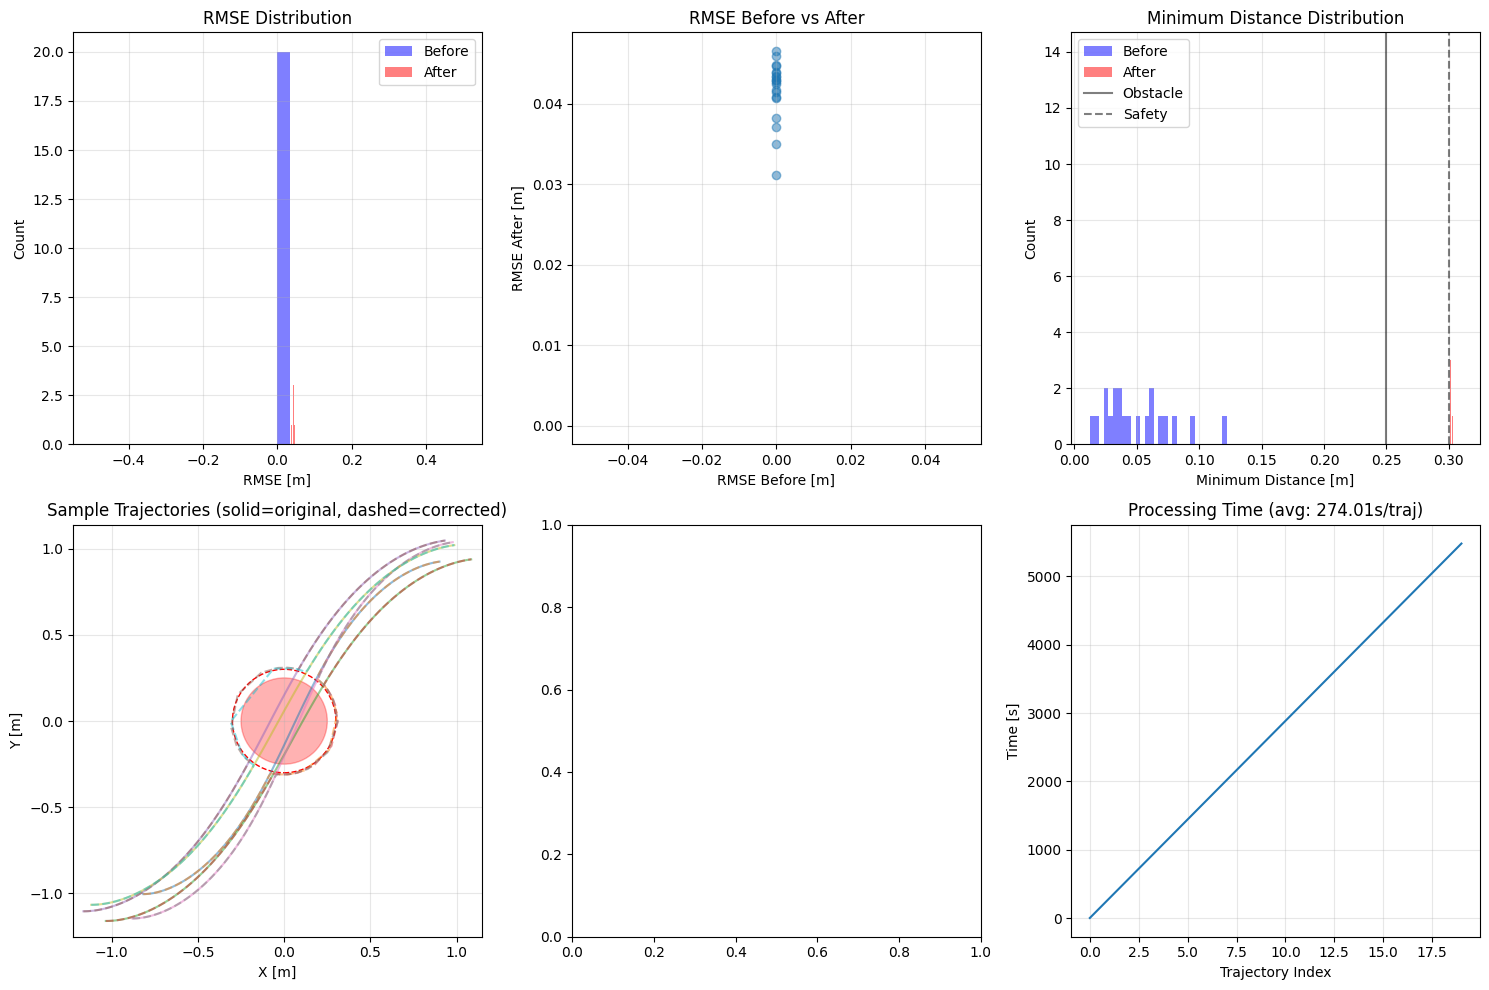


Batch processing complete! Results saved to 'cbf_clf_corrected_trajectories_ds.npz'


In [35]:
# === Cell: Batch CBF+CLF Processing ===

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from tqdm import tqdm
import time

# --- 0. 参数设置 ---
# CBF参数
# CBF参数
obstacle_center = np.array([0.0, 0.0])
obstacle_radius = 0.25
safety_margin = 0.05

# CLF参数
a_max = 10
delta_max = 10
dt = 0.1

# 权重参数（调整后）
w_dynamics = 5e3     # 降低动态一致性权重
w_state_reg = 0.1     # 降低状态修正正则化权重  
w_control_reg = 1.0   # 降低控制修正正则化权重
epsilon_cbf = 0.001   # CBF松弛变量

# 批处理参数
num_trajectories_to_process = 20
batch_save_filename = 'cbf_clf_corrected_trajectories_ds.npz'

# --- 1. 加载原始数据集 ---
print("Loading original trajectory dataset...")
trajectories = np.load('Car_trajectories_dataset.npy', allow_pickle=True)
print(f"Loaded {len(trajectories)} trajectories")

# --- 2. 辅助函数 ---
def simulate_vehicle(x0, u_seq, dt=0.1):
    """使用已有的车辆动力学仿真函数"""
    state_steps = len(u_seq) + 1
    states = np.zeros((state_steps, 5))
    states[0] = x0
    
    for k in range(len(u_seq)):
        x, y, theta, v, r = states[k]
        a, delta = u_seq[k]
        x_next = x + dt * v * np.cos(theta)
        y_next = y + dt * v * np.sin(theta)
        theta_next = theta + dt * r
        v_next = v + dt * a
        r_next = r + dt * delta
        states[k+1] = [x_next, y_next, theta_next, v_next, r_next]
    
    return states

def get_initial_cbf_projection(states_phys):
    """获取初始CBF投影"""
    N = states_phys.shape[0]
    states_init = states_phys.copy()
    
    for i in range(N):
        xy = states_phys[i, :2]
        dist = np.linalg.norm(xy - obstacle_center)
        if dist < obstacle_radius + safety_margin:
            direction = xy - obstacle_center
            if np.linalg.norm(direction) < 1e-6:
                direction = np.array([1.0, 0.0])
            else:
                direction = direction / np.linalg.norm(direction)
            states_init[i, :2] = obstacle_center + direction * (obstacle_radius + safety_margin + 0.01)
    
    return states_init

def joint_cbf_clf_optimization_batch(states_phys, controls_phys, 
                                     obstacle_center, obstacle_radius, safety_margin,
                                     a_max, delta_max, dt,
                                     w_dynamics, w_state_reg, w_control_reg, epsilon_cbf,
                                     max_iter=3,w_similarity=1.0):
    """批处理版本的CBF-CLF优化，速度优化"""
    N = states_phys.shape[0]
    
    # 获取初始CBF投影
    states_init = get_initial_cbf_projection(states_phys)
    states_original = states_phys.copy()
    # 当前最优解
    states_best = states_init.copy()
    controls_best = controls_phys.copy()
    
    # 迭代优化
    for iteration in range(max_iter):
        w_dyn_iter = w_dynamics * (0.5 ** iteration)
        
        def objective(dz_flat):
            ds = dz_flat[:3*N].reshape(N, 3)
            du = dz_flat[3*N:].reshape(N, 2)
            
            states_new = states_best + ds
            controls_new = controls_best + du
            
            # 动态一致性
            x0 = np.array([states_new[0,0], states_new[0,1], states_new[0,2], 0.0, 0.0])
            states_sim = simulate_vehicle(x0, controls_new[:-1], dt)[:, :3]
            dynamics_error = np.sum((states_sim - states_new)**2)
            
            # 正则化
            state_reg = np.sum(ds**2)
            control_reg = np.sum(du**2)
            
            state_similarity_weighted = (
                np.sum((states_new[:, :2] - states_original[:, :2])**2) * 2.0 +  # x,y位置
                np.sum((states_new[:, 2] - states_original[:, 2])**2) * 0.05      # 航向角
            )


            # CBF软约束
            cbf_violation = 0
            for k in range(N):
                xy = states_new[k, :2]
                h = np.sum((xy - obstacle_center)**2) - (obstacle_radius + safety_margin)**2
                if h < 0:
                    cbf_violation += (-h) ** 2
            
            cost = (w_dyn_iter * dynamics_error + 
                   w_state_reg * state_reg + 
                   w_control_reg * control_reg + w_similarity * state_similarity_weighted +
                   1000 * cbf_violation)
            
            return cost
        
        # 简化约束（每10个点检查）
        constraints = []
        for k in range(0, N, 10):
            def cbf_constraint(dz_flat, k=k):
                ds = dz_flat[:3*N].reshape(N, 3)
                xy_new = states_best[k, :2] + ds[k, :2]
                h = np.sum((xy_new - obstacle_center)**2) - (obstacle_radius + safety_margin - 0.05)**2
                return h
            
            constraints.append({
                'type': 'ineq',
                'fun': lambda dz, k=k: cbf_constraint(dz, k)
            })
        
        # 界限
        bounds = []
        state_bound = 0.3 / (iteration + 1)
        for k in range(N):
            bounds.extend([(-state_bound, state_bound), (-state_bound, state_bound), (-0.2, 0.2)])
        
        for k in range(N):
            a0, delta0 = controls_best[k]
            bounds.append((-a_max - a0, a_max - a0))
            bounds.append((-delta_max - delta0, delta_max - delta0))
        
        # 求解
        dz0 = np.zeros(5*N)
        result = minimize(
            objective, 
            dz0, 
            method='SLSQP',
            bounds=bounds,
            constraints=constraints,
            options={'ftol': 1e-6, 'maxiter': 300, 'disp': False}
        )
        
        if result.success:
            dz_opt = result.x
            ds_opt = dz_opt[:3*N].reshape(N, 3)
            du_opt = dz_opt[3*N:].reshape(N, 2)
            
            states_best = states_best + ds_opt
            controls_best = controls_best + du_opt
    
    return states_best, controls_best

# --- 3. 批处理 ---
print(f"\nProcessing {num_trajectories_to_process} trajectories...")

# 存储结果的列表
results_list = []

# 统计信息
total_rmse_before = []
total_rmse_after = []
total_min_dist_before = []
total_min_dist_after = []
total_violations_before = 0
total_violations_after = 0

# 处理每条轨迹
start_time = time.time()

for idx in tqdm(range(min(num_trajectories_to_process, len(trajectories)))):
    traj = trajectories[idx]
    
    # 提取状态和控制（只使用前3个状态维度）
    states_full = traj['states']  # (100, 5)
    states_phys = states_full[:, :3]  # (100, 3) - [x, y, theta]
    controls_phys = traj['controls'][:100]  # (100, 2) - [a, delta]
    
    # 执行CBF-CLF优化
    try:
        states_corrected, controls_corrected = joint_cbf_clf_optimization_batch(
            states_phys, controls_phys,
            obstacle_center, obstacle_radius, safety_margin,
            a_max, delta_max, dt,
            w_dynamics, w_state_reg, w_control_reg, epsilon_cbf,
            max_iter=2
        )
        
        # 仿真验证
        # 原始轨迹仿真
        x0_orig = np.array([states_phys[0,0], states_phys[0,1], states_phys[0,2], 0.0, 0.0])
        states_sim_orig = simulate_vehicle(x0_orig, controls_phys[:-1], dt)
        
        # 修正后轨迹仿真
        x0_corr = np.array([states_corrected[0,0], states_corrected[0,1], states_corrected[0,2], 0.0, 0.0])
        states_sim_corr = simulate_vehicle(x0_corr, controls_corrected[:-1], dt)
        
        # 计算RMSE
        rmse_before = np.sqrt(np.mean((states_phys[:, :2] - states_sim_orig[:, :2])**2))
        rmse_after = np.sqrt(np.mean((states_corrected[:, :2] - states_sim_corr[:, :2])**2))
        
        # 计算最小障碍物距离
        dist_before = np.linalg.norm(states_phys[:, :2] - obstacle_center, axis=1)
        dist_after = np.linalg.norm(states_corrected[:, :2] - obstacle_center, axis=1)
        min_dist_before = dist_before.min()
        min_dist_after = dist_after.min()
        
        # 计算违反次数
        violations_before = np.sum(dist_before < obstacle_radius + safety_margin)
        violations_after = np.sum(dist_after < obstacle_radius + safety_margin)
        
        # 存储结果
        result = {
            'idx': idx,
            'states_original': states_phys,
            'states_corrected': states_corrected,
            'controls_original': controls_phys,
            'controls_corrected': controls_corrected,
            'states_sim_original': states_sim_orig[:, :3],
            'states_sim_corrected': states_sim_corr[:, :3],
            'rmse_before': rmse_before,
            'rmse_after': rmse_after,
            'min_dist_before': min_dist_before,
            'min_dist_after': min_dist_after,
            'violations_before': violations_before,
            'violations_after': violations_after
        }
        results_list.append(result)
        
        # 更新统计
        total_rmse_before.append(rmse_before)
        total_rmse_after.append(rmse_after)
        total_min_dist_before.append(min_dist_before)
        total_min_dist_after.append(min_dist_after)
        total_violations_before += violations_before
        total_violations_after += violations_after
        
    except Exception as e:
        print(f"\nError processing trajectory {idx}: {e}")
        continue

end_time = time.time()
print(f"\nProcessing completed in {end_time - start_time:.1f} seconds")

# --- 4. 保存结果 ---
print("\nSaving results...")

# 准备数组形式的数据
num_processed = len(results_list)
states_original_arr = np.array([r['states_original'] for r in results_list])
states_corrected_arr = np.array([r['states_corrected'] for r in results_list])
controls_original_arr = np.array([r['controls_original'] for r in results_list])
controls_corrected_arr = np.array([r['controls_corrected'] for r in results_list])
rmse_before_arr = np.array([r['rmse_before'] for r in results_list])
rmse_after_arr = np.array([r['rmse_after'] for r in results_list])

# 保存为npz文件
np.savez(batch_save_filename,
    states_original=states_original_arr,
    states_corrected=states_corrected_arr,
    controls_original=controls_original_arr,
    controls_corrected=controls_corrected_arr,
    rmse_before=rmse_before_arr,
    rmse_after=rmse_after_arr,
    results_list=results_list,
    obstacle_center=obstacle_center,
    obstacle_radius=obstacle_radius,
    safety_margin=safety_margin
)

print(f"Results saved to '{batch_save_filename}'")

# --- 5. 统计分析 ---
print("\n=== Batch Processing Statistics ===")
print(f"Processed trajectories: {num_processed}")
print(f"\nRMSE Statistics:")
print(f"  Before CBF-CLF: mean={np.mean(total_rmse_before):.4f}, std={np.std(total_rmse_before):.4f}")
print(f"  After CBF-CLF:  mean={np.mean(total_rmse_after):.4f}, std={np.std(total_rmse_after):.4f}")
print(f"  Average improvement: {(np.mean(total_rmse_before) - np.mean(total_rmse_after))/np.mean(total_rmse_before)*100:.1f}%")

print(f"\nMinimum Distance to Obstacle:")
print(f"  Before: mean={np.mean(total_min_dist_before):.4f}, min={np.min(total_min_dist_before):.4f}")
print(f"  After:  mean={np.mean(total_min_dist_after):.4f}, min={np.min(total_min_dist_after):.4f}")

print(f"\nSafety Violations:")
print(f"  Total before: {total_violations_before}")
print(f"  Total after:  {total_violations_after}")
print(f"  Reduction: {(total_violations_before - total_violations_after)/max(total_violations_before, 1)*100:.1f}%")

# --- 6. 可视化统计结果 ---
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# RMSE直方图
ax1 = axes[0, 0]
ax1.hist(total_rmse_before, bins=30, alpha=0.5, label='Before', color='blue')
ax1.hist(total_rmse_after, bins=30, alpha=0.5, label='After', color='red')
ax1.set_xlabel('RMSE [m]')
ax1.set_ylabel('Count')
ax1.set_title('RMSE Distribution')
ax1.legend()
ax1.grid(True, alpha=0.3)

# RMSE改进散点图
ax2 = axes[0, 1]
ax2.scatter(total_rmse_before, total_rmse_after, alpha=0.5)
ax2.plot([0, max(total_rmse_before)], [0, max(total_rmse_before)], 'k--', alpha=0.5)
ax2.set_xlabel('RMSE Before [m]')
ax2.set_ylabel('RMSE After [m]')
ax2.set_title('RMSE Before vs After')
ax2.grid(True, alpha=0.3)

# 最小距离分布
ax3 = axes[0, 2]
ax3.hist(total_min_dist_before, bins=30, alpha=0.5, label='Before', color='blue')
ax3.hist(total_min_dist_after, bins=30, alpha=0.5, label='After', color='red')
ax3.axvline(x=obstacle_radius, color='k', linestyle='-', alpha=0.5, label='Obstacle')
ax3.axvline(x=obstacle_radius + safety_margin, color='k', linestyle='--', alpha=0.5, label='Safety')
ax3.set_xlabel('Minimum Distance [m]')
ax3.set_ylabel('Count')
ax3.set_title('Minimum Distance Distribution')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 选择几条轨迹可视化
sample_indices = np.random.choice(num_processed, min(5, num_processed), replace=False)

# 样本轨迹XY图
ax4 = axes[1, 0]
circle = plt.Circle(obstacle_center, obstacle_radius, color='red', alpha=0.3)
ax4.add_patch(circle)
circle_safe = plt.Circle(obstacle_center, obstacle_radius + safety_margin, 
                        color='red', fill=False, linestyle='--')
ax4.add_patch(circle_safe)

for i, idx in enumerate(sample_indices):
    result = results_list[idx]
    ax4.plot(result['states_original'][:, 0], result['states_original'][:, 1], 
             '-', alpha=0.5, label=f'Traj {idx}' if i < 3 else None)
    ax4.plot(result['states_corrected'][:, 0], result['states_corrected'][:, 1], 
             '--', alpha=0.5)

ax4.set_xlabel('X [m]')
ax4.set_ylabel('Y [m]')
ax4.set_title('Sample Trajectories (solid=original, dashed=corrected)')
ax4.axis('equal')
ax4.grid(True, alpha=0.3)
if len(sample_indices) <= 3:
    ax4.legend()

# # RMSE改进百分比
# ax5 = axes[1, 1]
# improvements = [(r['rmse_before'] - r['rmse_after'])/r['rmse_before']*100 
#                 for r in results_list]
# ax5.hist(improvements, bins=30, color='green', alpha=0.7)
# ax5.set_xlabel('RMSE Improvement [%]')
# ax5.set_ylabel('Count')
# ax5.set_title('RMSE Improvement Distribution')
# ax5.axvline(x=0, color='k', linestyle='--', alpha=0.5)
# ax5.grid(True, alpha=0.3)

# 处理时间估计
ax6 = axes[1, 2]
process_times = np.linspace(0, end_time - start_time, num_processed)
ax6.plot(process_times, label='Cumulative time')
ax6.set_xlabel('Trajectory Index')
ax6.set_ylabel('Time [s]')
ax6.set_title(f'Processing Time (avg: {(end_time-start_time)/num_processed:.2f}s/traj)')
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nBatch processing complete! Results saved to '{batch_save_filename}'")

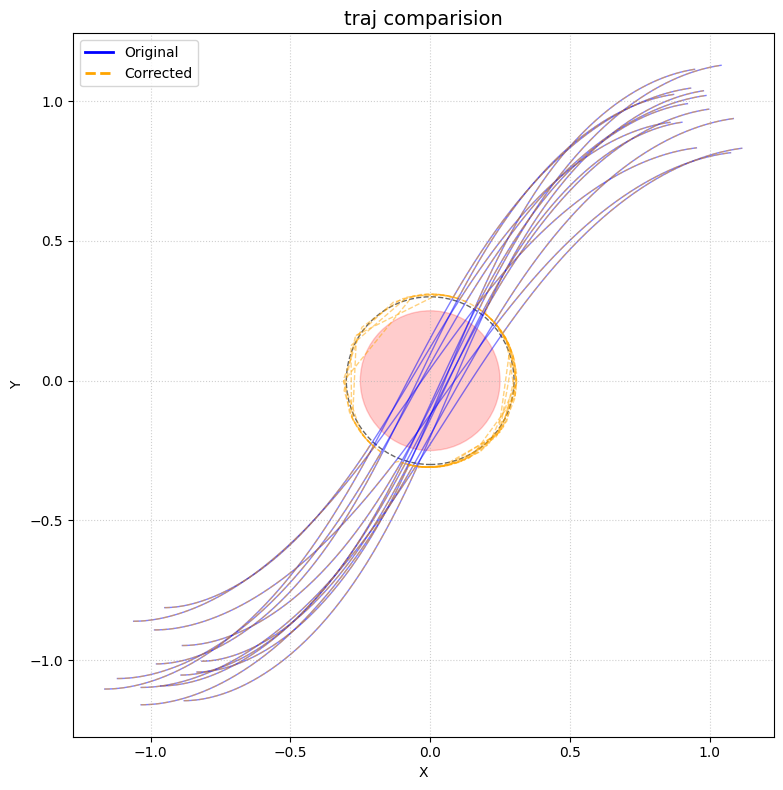

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# === Cell: 排除特定轨迹并可视化所有轨迹 ===

# 1. 加载已保存的批处理结果
data = np.load('cbf_clf_corrected_trajectories_ds.npz', allow_pickle=True)
states_original = data['states_original']      # (num_trajectories, N, 3)
states_corrected = data['states_corrected']    # (num_trajectories, N, 3)
obstacle_center = data['obstacle_center']
obstacle_radius = float(data['obstacle_radius'])
safety_margin = float(data['safety_margin'])

# 2. 定义要排除和保留的轨迹索引
exclude_idx = [3, 5, 7, 9, 11, 15]
num_traj = states_original.shape[0]
include_idx = [i for i in range(num_traj) if i not in exclude_idx]


fig2, ax2 = plt.subplots(figsize=(8, 8))
# 障碍物与安全边界
ax2.add_patch(Circle(obstacle_center, obstacle_radius, color='red', alpha=0.2))
ax2.add_patch(Circle(obstacle_center, obstacle_radius + safety_margin, 
                     fill=False, linestyle='--', alpha=0.6))
# 图例占位
ax2.plot([], [], color='blue', linewidth=2, label='Original')
ax2.plot([], [], color='orange', linestyle='--', linewidth=2, label='Corrected')

for idx in include_idx:
    orig = states_original[idx]
    corr = states_corrected[idx]
    ax2.plot(orig[:, 0], orig[:, 1], color='blue', linewidth=1, alpha=0.5)
    ax2.plot(corr[:, 0], corr[:, 1], color='orange', linestyle='--', linewidth=1, alpha=0.5)

ax2.set_aspect('equal', 'box')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_title('traj comparision', fontsize=14)
ax2.legend(loc='best')
ax2.grid(True, linestyle=':', alpha=0.6)

fig2.tight_layout()
plt.show()


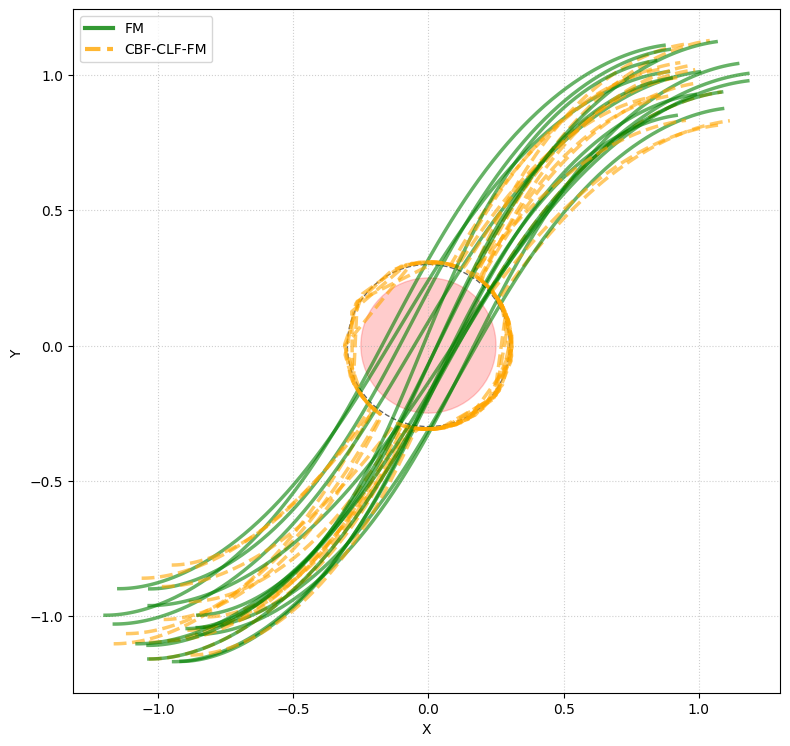

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# === Cell: 随机抽取同数量 FM 轨迹，并与 CBF-CLF-FM 修正结果对比 ===

# 1. 加载 CBF-CLF 批处理结果
batch = np.load('cbf_clf_corrected_trajectories_ds.npz', allow_pickle=True)
states_corrected = batch['states_corrected']    # (20, N, 3)
obstacle_center = batch['obstacle_center']
obstacle_radius = float(batch['obstacle_radius'])
safety_margin = float(batch['safety_margin'])

# 2. 确定要可视化的索引（排除 3,5,7,9,11,15）
exclude_idx = [3, 5, 7, 9, 11, 15]
include_idx = [i for i in range(states_corrected.shape[0]) if i not in exclude_idx]
n = len(include_idx)

# 3. 从过滤后的FM数据集中随机抽取 n 条轨迹
fm_data = np.load('Car_trajectories_dataset_filtered.npy', allow_pickle=True)
indices = np.random.choice(len(fm_data), size=n, replace=False)
fm_trajs = [fm_data[i]['states'][:, :2] for i in indices]

# 4. 绘制所有轨迹叠加图
fig, ax = plt.subplots(figsize=(8, 8))

# 障碍物与安全边界
ax.add_patch(Circle(obstacle_center, obstacle_radius, color='red', alpha=0.2))
ax.add_patch(Circle(obstacle_center, obstacle_radius + safety_margin,
                     fill=False, linestyle='--', alpha=0.6))

# 占位图例
ax.plot([], [], color='green', linewidth=3, label='FM', alpha=0.8)
ax.plot([], [], color='orange', linestyle='--', linewidth=3, label='CBF-CLF-FM', alpha=0.8)

# 绘制轨迹
for i, idx in enumerate(include_idx):
    fm = fm_trajs[i]
    corr = states_corrected[idx][:, :2]
    ax.plot(fm[:, 0], fm[:, 1], color='green', linewidth=2.5, alpha=0.6)
    ax.plot(corr[:, 0], corr[:, 1], color='orange', linestyle='--', linewidth=2.5, alpha=0.6)

# 样式
ax.set_aspect('equal', 'box')
ax.set_xlabel('X')
ax.set_ylabel('Y ')
ax.set_title('', fontsize=16)
ax.legend(loc='best')
ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


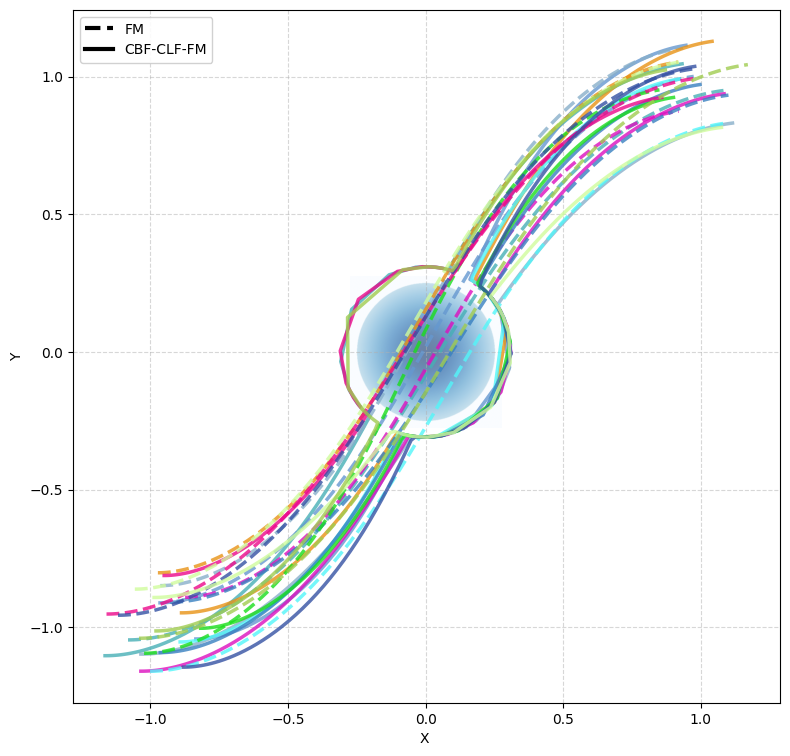

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# === Cell: 蓝色渐变 & 边缘更浅可视化 ===

# 1. 加载 CBF-CLF 修正结果
batch = np.load('cbf_clf_corrected_trajectories_ds.npz', allow_pickle=True)
states_corrected = batch['states_corrected']
obstacle_center = batch['obstacle_center']
obstacle_radius = float(batch['obstacle_radius'])
safety_margin = float(batch['safety_margin'])

# 2. 确定要可视化的轨迹索引（排除 3,5,7,9,11,15）
exclude_idx = [3, 5, 7, 9, 10,11, 15,18]
include_idx = [i for i in range(states_corrected.shape[0]) if i not in exclude_idx]
n = len(include_idx)

# 3. 从过滤后的 FM 数据集中抽取 n 条轨迹
fm_data = np.load('Car_trajectories_dataset_filtered.npy', allow_pickle=True)
rand_indices = np.random.choice(len(fm_data), size=n, replace=False)
fm_trajs = [fm_data[i]['states'][:, :2] for i in rand_indices]

# 4. 绘制
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_aspect('equal', 'box')
ax.set_axisbelow(True)
ax.grid(True, linestyle='--', alpha=0.5)

# 障碍物蓝色 Gaussian 渐变（边缘更浅）
res = 500
x = np.linspace(obstacle_center[0] - obstacle_radius*1.1, 
                obstacle_center[0] + obstacle_radius*1.1, res)
y = np.linspace(obstacle_center[1] - obstacle_radius*1.1, 
                obstacle_center[1] + obstacle_radius*1.1, res)
X, Y = np.meshgrid(x, y)
R = np.sqrt((X - obstacle_center[0])**2 + (Y - obstacle_center[1])**2)
Z = np.exp(- (R/obstacle_radius)**2)
Z[R > obstacle_radius] = 0
ax.imshow(Z, extent=[x.min(), x.max(), y.min(), y.max()],
          origin='lower', cmap='Blues', alpha=0.6, interpolation='bilinear')

# 图例占位
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='black', linestyle='--', lw=3, label='FM'),
    Line2D([0], [0], color='black', linestyle='-', lw=3, label='CBF-CLF-FM')
]
ax.legend(handles=legend_elements, loc='best', framealpha=0.9)

# 随机颜色绘制轨迹
for i, idx in enumerate(include_idx):
    color = np.random.rand(3,)
    fm = fm_trajs[i]
    corr = states_corrected[idx][:, :2]
    ax.plot(fm[:, 0], fm[:, 1], linestyle='--', color=color, linewidth=2.5, alpha=0.8)
    ax.plot(corr[:, 0], corr[:, 1], linestyle='-', color=color, linewidth=2.5, alpha=0.8)

ax.set_xlabel('X ')
ax.set_ylabel('Y')
ax.set_title('', fontsize=16)
plt.tight_layout()
plt.show()



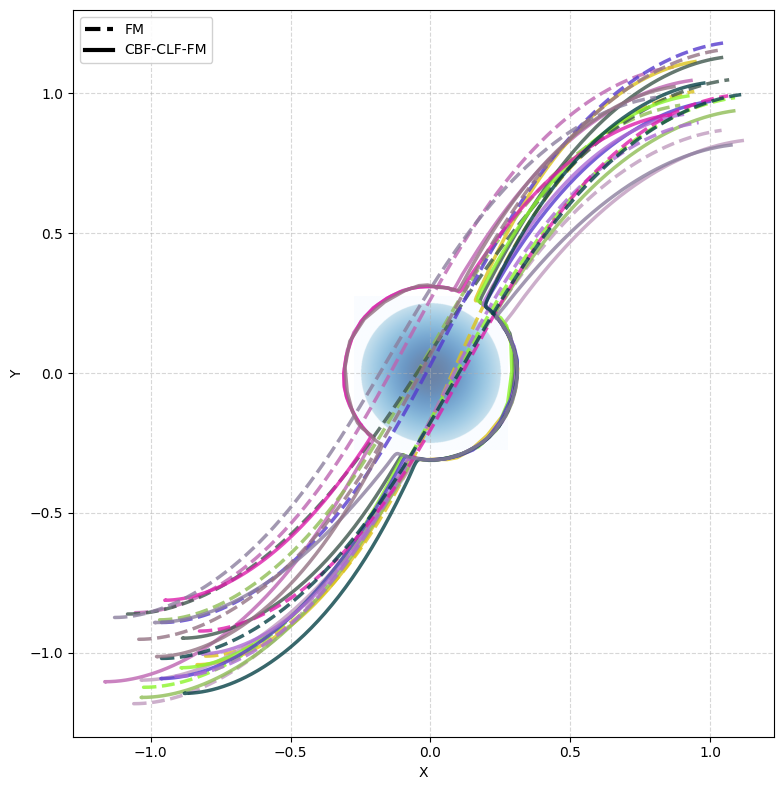

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from matplotlib.lines import Line2D

# === Cell: 插值平滑后可视化 ===

# 1. 加载 CBF-CLF 修正结果
batch = np.load('cbf_clf_corrected_trajectories_ds.npz', allow_pickle=True)
states_corrected = batch['states_corrected']    # (20, N, 3)
obstacle_center = batch['obstacle_center']
obstacle_radius = float(batch['obstacle_radius'])
safety_margin = float(batch['safety_margin'])

# 2. 确定排除与包含索引
exclude_idx = [3, 5, 7, 9, 10, 11, 15, 18]
include_idx = [i for i in range(states_corrected.shape[0]) if i not in exclude_idx]
n = len(include_idx)

# 3. 加载并随机抽取 FM 基线轨迹
fm_data = np.load('Car_trajectories_dataset_filtered.npy', allow_pickle=True)
rand_indices = np.random.choice(len(fm_data), size=n, replace=False)
fm_trajs = [fm_data[i]['states'][:, :2] for i in rand_indices]

# 4. 绘制并插值平滑
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_aspect('equal', 'box')
ax.set_axisbelow(True)
ax.grid(True, linestyle='--', alpha=0.5)

# 障碍物蓝色渐变
res = 500
x = np.linspace(obstacle_center[0] - obstacle_radius*1.1, obstacle_center[0] + obstacle_radius*1.1, res)
y = np.linspace(obstacle_center[1] - obstacle_radius*1.1, obstacle_center[1] + obstacle_radius*1.1, res)
X, Y = np.meshgrid(x, y)
R = np.sqrt((X - obstacle_center[0])**2 + (Y - obstacle_center[1])**2)
Z = np.exp(- (R/obstacle_radius)**2)
Z[R > obstacle_radius] = 0
ax.imshow(Z, extent=[x.min(), x.max(), y.min(), y.max()],
          origin='lower', cmap='Blues', alpha=0.6, interpolation='bilinear')

# 图例代理
legend_elements = [
    Line2D([0], [0], color='black', linestyle='--', lw=3, label='FM'),
    Line2D([0], [0], color='black', linestyle='-', lw=3, label='CBF-CLF-FM')
]
ax.legend(handles=legend_elements, loc='best', framealpha=0.9)

# 插值并绘制每条轨迹
for i, idx in enumerate(include_idx):
    fm = fm_trajs[i]
    corr = states_corrected[idx][:, :2]
    L = fm.shape[0]
    t = np.linspace(0, 1, L)
    t_new = np.linspace(0, 1, L * 3)
    fm_fx = interp1d(t, fm[:, 0], kind='cubic')
    fm_fy = interp1d(t, fm[:, 1], kind='cubic')
    cf_fx = interp1d(t, corr[:, 0], kind='cubic')
    cf_fy = interp1d(t, corr[:, 1], kind='cubic')
    # 计算平滑点
    fm_smooth = np.vstack((fm_fx(t_new), fm_fy(t_new))).T
    cf_smooth = np.vstack((cf_fx(t_new), cf_fy(t_new))).T
    color = np.random.rand(3,)
    ax.plot(fm_smooth[:, 0], fm_smooth[:, 1], linestyle='--', color=color, linewidth=2.5, alpha=0.8)
    ax.plot(cf_smooth[:, 0], cf_smooth[:, 1], linestyle='-', color=color, linewidth=2.5, alpha=0.8)

ax.set_xlabel('X')
ax.set_ylabel('Y')
plt.tight_layout()
plt.show()


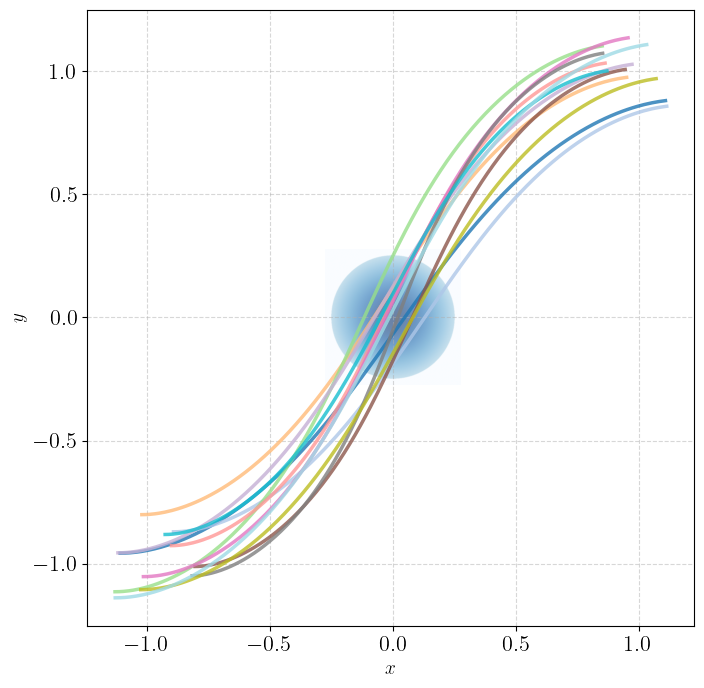

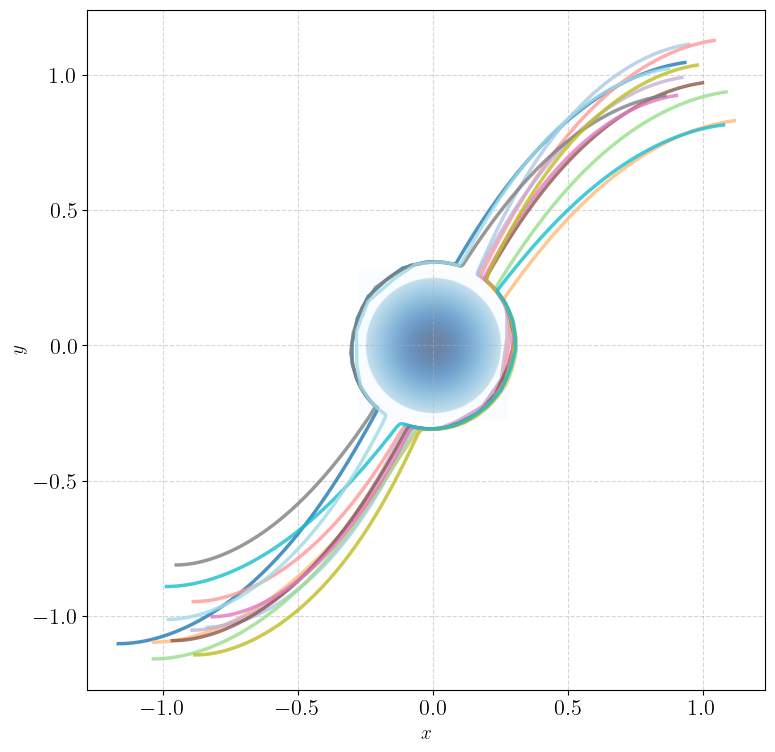

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# === 1. 数据加载 ===
batch = np.load('cbf_clf_corrected_trajectories_ds.npz', allow_pickle=True)
states_corrected = batch['states_corrected']
obstacle_center = batch['obstacle_center']
obstacle_radius = float(batch['obstacle_radius'])
safety_margin = float(batch['safety_margin'])

exclude_idx = [3, 5, 7, 9, 10, 11, 15, 18]
include_idx = [i for i in range(states_corrected.shape[0]) if i not in exclude_idx]
n = len(include_idx)

fm_data = np.load('Car_trajectories_dataset_filtered.npy', allow_pickle=True)
rand_indices = np.random.choice(len(fm_data), size=n, replace=False)
fm_trajs = [fm_data[i]['states'][:, :2] for i in rand_indices]

# === 2. 生成 tab20 颜色列表 ===
colors = plt.cm.tab20(np.linspace(0, 1, n))

# === 3. 绘制障碍物背景 ===
def plot_obstacle(ax):
    res = 500
    x = np.linspace(obstacle_center[0] - obstacle_radius*1.1,
                    obstacle_center[0] + obstacle_radius*1.1, res)
    y = np.linspace(obstacle_center[1] - obstacle_radius*1.1,
                    obstacle_center[1] + obstacle_radius*1.1, res)
    X, Y = np.meshgrid(x, y)
    R = np.sqrt((X - obstacle_center[0])**2 + (Y - obstacle_center[1])**2)
    Z = np.exp(- (R/obstacle_radius)**2)
    Z[R > obstacle_radius] = 0
    ax.imshow(Z, extent=[x.min(), x.max(), y.min(), y.max()],
              origin='lower', cmap='Blues', alpha=0.6, interpolation='bilinear')

# === 4. 线性插值平滑 ===
def smooth_traj(traj, num_points=200):
    t_orig = np.linspace(0, 1, traj.shape[0])
    t_new  = np.linspace(0, 1, num_points)
    fx = interp1d(t_orig, traj[:, 0], kind='linear')
    fy = interp1d(t_orig, traj[:, 1], kind='linear')
    x_new = fx(t_new)
    y_new = fy(t_new)
    return np.vstack((x_new, y_new)).T

# === 5. 未校正轨迹 (FM) ===
fig1, ax1 = plt.subplots(figsize=(8, 8))
ax1.set_aspect('equal', 'box')
ax1.grid(True, linestyle='--', alpha=0.5)
plot_obstacle(ax1)

for k, traj in enumerate(fm_trajs):
    traj_s = smooth_traj(traj)
    ax1.plot(traj_s[:, 0], traj_s[:, 1],
             linewidth=2.5, alpha=0.8, color=colors[k])

ax1.set_xlabel(r'$x$', fontsize=14)
ax1.set_ylabel(r'$y$', fontsize=14)
# ax1.set_title('Uncorrected Trajectories')

# === 6. 校正后轨迹 (CBF-CLF-FM) ===
fig2, ax2 = plt.subplots(figsize=(8, 8))
ax2.set_aspect('equal', 'box')
ax2.grid(True, linestyle='--', alpha=0.5)
plot_obstacle(ax2)

for k, idx in enumerate(include_idx):
    corr = states_corrected[idx][:, :2]
    corr_s = smooth_traj(corr)
    ax2.plot(corr_s[:, 0], corr_s[:, 1],
             linewidth=2.5, alpha=0.8, color=colors[k])

ax2.set_xlabel(r'$x$', fontsize=14)
ax2.set_ylabel(r'$y$', fontsize=14)
# ax2.set_title('Corrected Trajectories')

plt.tight_layout()
plt.show()


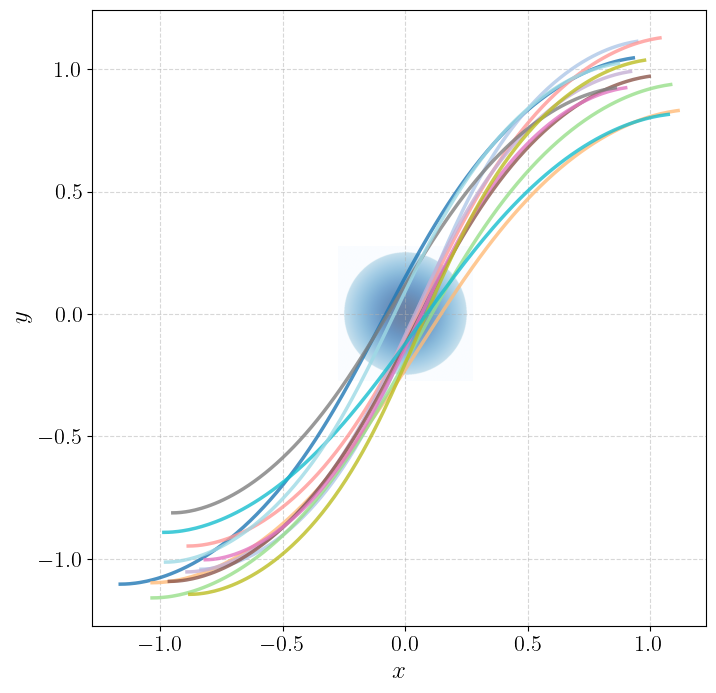

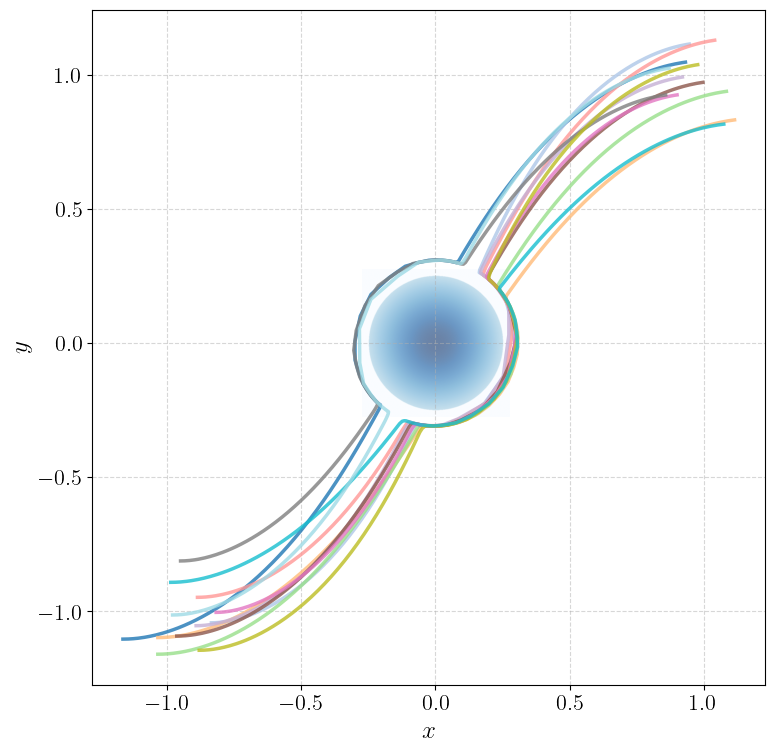

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.interpolate import interp1d

# === 0. 配置 Matplotlib 使用外部 LaTeX 渲染 ===
# 这三行会让 Matplotlib 在渲染所有文本时调用系统 LaTeX，
# 并且加载 amsmath、amsfonts 宏包、以及使用 Computer Modern 字体系列。
mpl.rc('text', usetex=True)
mpl.rc('text.latex', preamble=r'\usepackage{amsmath,amsfonts}')
mpl.rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
mpl.rcParams.update({'font.size': 16})

# === 1. 数据加载 ===
data = np.load('cbf_clf_corrected_trajectories_ds.npz', allow_pickle=True)
states_original  = data['states_original']   # (num_traj, T, 3)
states_corrected = data['states_corrected']  # (num_traj, T, 3)
obstacle_center  = data['obstacle_center']
obstacle_radius  = float(data['obstacle_radius'])
safety_margin    = float(data['safety_margin'])

# 排除索引（如有需要）
# exclude_idx = [3, 5, 7, 9, 11, 15]
num_traj = states_original.shape[0]
include_idx = [i for i in range(num_traj) if i not in exclude_idx]
n = len(include_idx)

# === 2. 生成 tab20 颜色列表 ===
# tab20 一共 20 种颜色，按需要从中均匀取 n 色
colors = plt.cm.tab20(np.linspace(0, 1, n))

# === 3. 障碍物高斯背景函数 ===
def plot_obstacle(ax):
    res = 500
    x = np.linspace(obstacle_center[0] - obstacle_radius*1.1,
                    obstacle_center[0] + obstacle_radius*1.1, res)
    y = np.linspace(obstacle_center[1] - obstacle_radius*1.1,
                    obstacle_center[1] + obstacle_radius*1.1, res)
    X, Y = np.meshgrid(x, y)
    R = np.sqrt((X - obstacle_center[0])**2 + (Y - obstacle_center[1])**2)
    Z = np.exp(- (R/obstacle_radius)**2)
    Z[R > obstacle_radius] = 0
    ax.imshow(Z,
              extent=[x.min(), x.max(), y.min(), y.max()],
              origin='lower', cmap='Blues',
              alpha=0.6, interpolation='bilinear')

# === 4. 线性插值平滑函数 ===
def smooth_traj(traj, num_points=200):
    t0 = np.linspace(0, 1, traj.shape[0])
    t1 = np.linspace(0, 1, num_points)
    fx = interp1d(t0, traj[:,0], kind='linear')
    fy = interp1d(t0, traj[:,1], kind='linear')
    x1 = fx(t1);  y1 = fy(t1)
    return np.vstack((x1, y1)).T

# === 5. 绘制原始轨迹 ===
fig1, ax1 = plt.subplots(figsize=(8, 8))
ax1.set_aspect('equal', 'box')
ax1.grid(True, linestyle='--', alpha=0.5)
plot_obstacle(ax1)

for k, idx in enumerate(include_idx):
    traj = states_original[idx][:, :2]
    traj_s = smooth_traj(traj)
    ax1.plot(traj_s[:,0], traj_s[:,1],
             linewidth=2.5, alpha=0.8, color=colors[k])

# 使用外部 LaTeX 渲染的坐标轴标签（仅保留 X 和 Y）
ax1.set_xlabel(r'$x$', fontsize=18)
ax1.set_ylabel(r'$y$', fontsize=18)

# === 6. 绘制校正后轨迹 ===
fig2, ax2 = plt.subplots(figsize=(8, 8))
ax2.set_aspect('equal', 'box')
ax2.grid(True, linestyle='--', alpha=0.5)
plot_obstacle(ax2)

for k, idx in enumerate(include_idx):
    traj = states_corrected[idx][:, :2]
    traj_s = smooth_traj(traj)
    ax2.plot(traj_s[:,0], traj_s[:,1],
             linewidth=2.5, alpha=0.8, color=colors[k])

# 同样用 LaTeX 渲染标签
ax2.set_xlabel(r'$x$', fontsize=18)
ax2.set_ylabel(r'$y$', fontsize=18)

plt.tight_layout()
plt.show()


Loading trajectory dataset...
Loaded 1000 trajectories

Analyzing RMSE for 100 samples...


100%|██████████| 100/100 [00:00<00:00, 2197.27it/s]


=== CBF Projection vs Original Control Simulation RMSE Analysis ===
Number of samples processed: 100
RMSE Statistics:
  Mean: 0.056491 m
  Standard Deviation: 0.008103 m
  Minimum: 0.028787 m
  Maximum: 0.068526 m
  Median: 0.059255 m


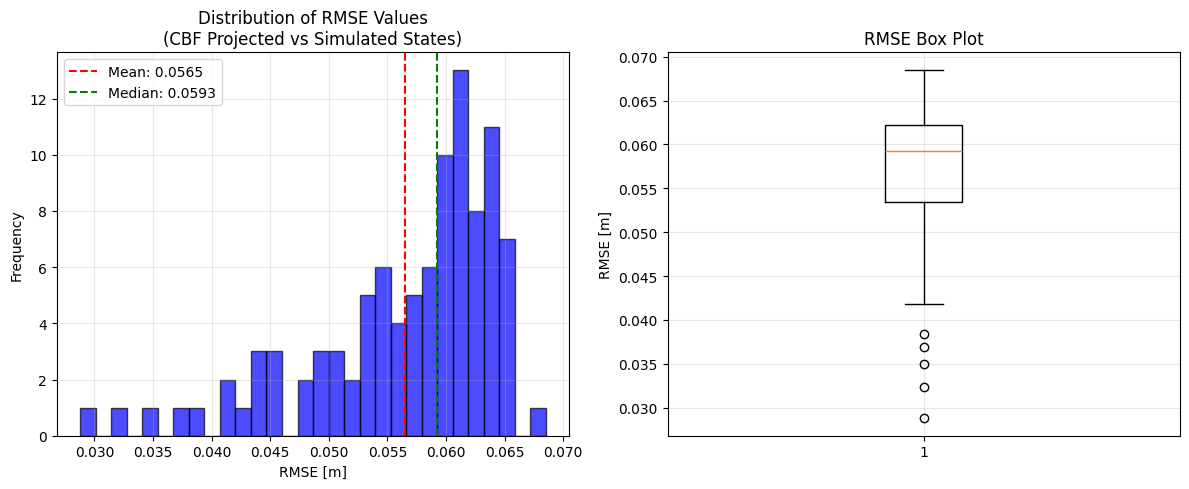


=== Additional Analysis ===
25th percentile: 0.053452 m
50th percentile: 0.059255 m
75th percentile: 0.062173 m
90th percentile: 0.064323 m
95th percentile: 0.064933 m
99th percentile: 0.065855 m

Trajectories with RMSE > μ + 2σ (0.0727 m): 0 (0.0%)

Results saved to 'cbf_projection_rmse_analysis.npz'


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from tqdm import tqdm

# --- 0. Parameters from the original code ---
obstacle_center = np.array([0.0, 0.0])
obstacle_radius = 0.25
safety_margin = 0.05
dt = 0.1
state_steps = 100
control_steps = state_steps - 1

# --- 1. Vehicle simulation function (from original code) ---
def simulate_vehicle(x0, u_seq, dt=0.1):
    """
    Simulate the vehicle dynamics.
    
    x0: initial state [x, y, theta, v, r]
    u_seq: control sequence of shape (control_steps, 2), for each step: [a, delta]
    
    Returns:
      states: NumPy array of shape (state_steps, 5)
    """
    state_steps = len(u_seq) + 1
    states = np.zeros((state_steps, 5))
    states[0] = x0
    
    for k in range(len(u_seq)):
        x, y, theta, v, r = states[k]
        a, delta = u_seq[k]
        x_next = x + dt * v * np.cos(theta)
        y_next = y + dt * v * np.sin(theta)
        theta_next = theta + dt * r
        v_next = v + dt * a
        r_next = r + dt * delta
        states[k+1] = [x_next, y_next, theta_next, v_next, r_next]
    
    return states

# --- 2. CBF projection function ---
def cbf_projection_with_mask(xy_traj):
    """
    Project trajectory points to satisfy CBF constraint with modification tracking.
    
    Args:
        xy_traj: (N, 2) array of xy positions
    
    Returns:
        xy_projected: (N, 2) array of projected positions
        modification_mask: (N,) boolean array indicating which points were modified
    """
    N = xy_traj.shape[0]
    xy_projected = xy_traj.copy()
    modification_mask = np.zeros(N, dtype=bool)
    
    for i in range(N):
        xy = xy_traj[i]
        dist = np.linalg.norm(xy - obstacle_center)
        
        if dist < obstacle_radius + safety_margin:
            # Project to safety boundary
            direction = xy - obstacle_center
            if np.linalg.norm(direction) < 1e-6:
                direction = np.array([1.0, 0.0])
            else:
                direction = direction / np.linalg.norm(direction)
            
            xy_projected[i] = obstacle_center + direction * (obstacle_radius + safety_margin + 0.01)
            modification_mask[i] = True
    
    return xy_projected, modification_mask

def reconstruct_heading_smart(xy_original, xy_projected, theta_original, modification_mask):
    """
    Reconstruct heading angles for projected trajectory.
    """
    theta_reconstructed = theta_original.copy()
    N = len(theta_original)
    
    for i in range(N):
        if modification_mask[i]:
            if i == 0:
                # Use next point if available
                if N > 1:
                    direction = xy_projected[1] - xy_projected[0]
                    if np.linalg.norm(direction) > 1e-6:
                        theta_reconstructed[i] = np.arctan2(direction[1], direction[0])
            elif i == N-1:
                # Use previous point
                direction = xy_projected[i] - xy_projected[i-1]
                if np.linalg.norm(direction) > 1e-6:
                    theta_reconstructed[i] = np.arctan2(direction[1], direction[0])
            else:
                # Use central difference
                direction = xy_projected[i+1] - xy_projected[i-1]
                if np.linalg.norm(direction) > 1e-6:
                    theta_reconstructed[i] = np.arctan2(direction[1], direction[0])
    
    return theta_reconstructed

# --- 3. Load trajectory dataset ---
print("Loading trajectory dataset...")
trajectories = np.load('Car_trajectories_dataset.npy', allow_pickle=True)
print(f"Loaded {len(trajectories)} trajectories")

# --- 4. Analyze 100 samples ---
num_samples = min(100, len(trajectories))
rmse_values = []

print(f"\nAnalyzing RMSE for {num_samples} samples...")

for idx in tqdm(range(num_samples)):
    try:
        traj = trajectories[idx]
        
        # Extract original states and controls
        states_original = traj['states']  # (100, 5)
        controls_original = traj['controls'][:control_steps]  # (99, 2)
        
        # Extract XY positions and heading
        xy_original = states_original[:, :2]  # (100, 2)
        theta_original = states_original[:, 2]  # (100,)
        
        # Apply CBF projection
        xy_cbf, modification_mask = cbf_projection_with_mask(xy_original)
        theta_cbf = reconstruct_heading_smart(xy_original, xy_cbf, theta_original, modification_mask)
        
        # Create CBF projected states (keeping v=0, r=0 as in original)
        states_cbf = np.column_stack([xy_cbf, theta_cbf, 
                                     np.zeros(state_steps), 
                                     np.zeros(state_steps)])  # (100, 5)
        
        # Simulate vehicle dynamics using original controls
        x0_sim = np.array([states_original[0,0], states_original[0,1], states_original[0,2], 0.0, 0.0])
        states_simulated = simulate_vehicle(x0_sim, controls_original, dt)
        
        # Calculate RMSE between CBF projected states and simulated states
        # Focus on position (x, y) for RMSE calculation
        cbf_positions = states_cbf[:, :2]
        sim_positions = states_simulated[:, :2]
        
        # RMSE calculation
        position_errors = np.linalg.norm(cbf_positions - sim_positions, axis=1)
        rmse = np.sqrt(np.mean(position_errors**2))
        
        rmse_values.append(rmse)
        
    except Exception as e:
        print(f"\nError processing trajectory {idx}: {e}")
        continue

# --- 5. Calculate statistics ---
rmse_values = np.array(rmse_values)

print(f"\n=== CBF Projection vs Original Control Simulation RMSE Analysis ===")
print(f"Number of samples processed: {len(rmse_values)}")
print(f"RMSE Statistics:")
print(f"  Mean: {np.mean(rmse_values):.6f} m")
print(f"  Standard Deviation: {np.std(rmse_values):.6f} m")
print(f"  Minimum: {np.min(rmse_values):.6f} m")
print(f"  Maximum: {np.max(rmse_values):.6f} m")
print(f"  Median: {np.median(rmse_values):.6f} m")

# --- 6. Visualization ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Histogram of RMSE values
ax1.hist(rmse_values, bins=30, alpha=0.7, color='blue', edgecolor='black')
ax1.axvline(np.mean(rmse_values), color='red', linestyle='--', 
           label=f'Mean: {np.mean(rmse_values):.4f}')
ax1.axvline(np.median(rmse_values), color='green', linestyle='--', 
           label=f'Median: {np.median(rmse_values):.4f}')
ax1.set_xlabel('RMSE [m]')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of RMSE Values\n(CBF Projected vs Simulated States)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Box plot
ax2.boxplot(rmse_values, vert=True)
ax2.set_ylabel('RMSE [m]')
ax2.set_title('RMSE Box Plot')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- 7. Additional analysis ---
print(f"\n=== Additional Analysis ===")
percentiles = [25, 50, 75, 90, 95, 99]
for p in percentiles:
    value = np.percentile(rmse_values, p)
    print(f"{p}th percentile: {value:.6f} m")

# Count how many trajectories have high RMSE (indicating significant discrepancy)
high_rmse_threshold = np.mean(rmse_values) + 2 * np.std(rmse_values)
high_rmse_count = np.sum(rmse_values > high_rmse_threshold)
print(f"\nTrajectories with RMSE > μ + 2σ ({high_rmse_threshold:.4f} m): {high_rmse_count} ({high_rmse_count/len(rmse_values)*100:.1f}%)")

# Save results
np.savez('cbf_projection_rmse_analysis.npz',
         rmse_values=rmse_values,
         mean_rmse=np.mean(rmse_values),
         std_rmse=np.std(rmse_values),
         obstacle_center=obstacle_center,
         obstacle_radius=obstacle_radius,
         safety_margin=safety_margin)

print(f"\nResults saved to 'cbf_projection_rmse_analysis.npz'")